# Проект: семантический поиск товаров по текстовому запросу

**Задача.** Построить MVP системы семантического поиска query-to-item (запрос → top-K карточек товара), сравнить его с лексическим baseline на подготовленной разметке и дать бизнесу обоснованную рекомендацию: где новое решение помогает, где ошибается и стоит ли его внедрять.

## Данные

| Файл | Что это |
|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории |
| wb_products_dedup.parquet | Множество товаров, по которому делалась разметка |
| queries_synthetic_train.parquet | Разметка релевантности, train |
| queries_synthetic_test.parquet | Разметка релевантности, test |

Файлы с разметкой содержат столбцы `query_id`, `query_text`, `item_id`, `relevance`. Шкала `relevance` - от `0` (нерелевантен) до `3` (максимально релевантен). Связь с каталогом: `item_id` ↔ `imt_id`.

Файлы скачиваются из бакета `s3-ds-source` в локальную папку `data/`, которая не хранится в репозитории. Ключи доступа читаются из локального `.env` (образец - `.env.example`).

## Окружение и воспроизводимость

Фиксируем версии библиотек, единый `SEED`, пути и вычислительное устройство. Все случайные операции тетради используют этот `SEED`.

In [1]:
from __future__ import annotations

import os

# Без индикаторов загрузки модели в выводе тетради
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

import hashlib
import importlib.metadata
import json
import math
import random
import re
import sys
from collections.abc import Callable, Iterable
from html import unescape
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from botocore.config import Config
from IPython.display import HTML, display
from mlflow.tracking import MlflowClient
from scipy import sparse
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from torch import nn
from torch.nn import functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"

ROOT = Path.cwd().resolve()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)


def load_local_env(path: Path) -> bool:
    """Читает KEY=value из локального .env, не перезаписывая уже заданные переменные и не печатая значения."""
    if not path.exists():
        return False
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", maxsplit=1)
        key, value = key.strip(), value.strip().strip('"').strip("'")
        if key and key not in os.environ:
            os.environ[key] = value
    return True


dotenv_found = load_local_env(ROOT / ".env")
environment = pd.Series({
    "python": sys.version.split()[0],
    **{lib: importlib.metadata.version(lib) for lib in [
        "pandas", "numpy", "pyarrow", "scikit-learn", "sentence-transformers", "torch", "mlflow", "boto3", "matplotlib", "seaborn",
    ]},
    "seed": SEED,
    "device": DEVICE,
    "data_dir": str(DATA_DIR),
    "artifact_dir": str(ARTIFACT_DIR),
    "local_env_found": dotenv_found,
}).to_frame("value")
display(environment)

,value
python,3.12.6
pandas,2.2.3
numpy,1.26.4
pyarrow,23.0.1
scikit-learn,1.6.1
sentence-transformers,5.5.1
torch,2.12.0
mlflow,3.10.0
boto3,1.43.36
matplotlib,3.9.4


In [2]:
# Необходимые файлы

RAW_PRODUCTS_PATH = DATA_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = DATA_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = DATA_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = DATA_DIR / "queries_synthetic_test.parquet"


def ensure_local_copy(path: Path) -> Path:
    """Скачивает файл проекта из S3 в data/, если локальной копии ещё нет. Исходные объекты в S3 не изменяются."""
    if path.exists():
        return path
    for name in ("AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"):
        if not os.getenv(name):
            raise RuntimeError(f"{name} не задан: заполните локальный .env по образцу .env.example")
    client = boto3.client(
        "s3",
        endpoint_url=os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net"),
        aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
        aws_session_token=os.getenv("AWS_SESSION_TOKEN") or None,
        # Системный прокси macOS может указывать на недоступный loopback-адрес; к хранилищу курса обращаемся напрямую.
        config=Config(proxies={}),
    )
    client.download_file(os.getenv("S3_BUCKET", "s3-ds-source"), path.name, str(path))
    return path


source_files = pd.DataFrame(
    [{"file": p.name, "bytes": ensure_local_copy(p).stat().st_size} for p in
     (RAW_PRODUCTS_PATH, ASSESSED_POOL_PATH, TRAIN_QUERIES_PATH, TEST_QUERIES_PATH)]
)
display(source_files)

,file,bytes
0,wb_products_raw_sample.parquet,41583424
1,wb_products_dedup.parquet,1482403
2,queries_synthetic_train.parquet,48191
3,queries_synthetic_test.parquet,27050


---

## Неделя 1 - знакомство с данными и EDA

**Цель** - понять данные, чтобы обоснованно выбрать категории, правила очистки описаний и поля для текста товара. Каждое решение ниже опирается на таблицу или график, расположенные выше него.

### 1. Загрузка данных

Загружаем каталог и обе разметки, смотрим колонки и типы. `imt_id` - карточка товара, `nm_id` - артикул (вариант карточки по цвету, размеру и т. п.). Test-разметка загружается здесь только для проверки ключей и отсутствия пересечения запросов с train; её оценки `relevance` не используются до финального прогона.

In [3]:
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
queries_test = pd.read_parquet(TEST_QUERIES_PATH)

PRODUCT_COLUMNS = {"imt_id", "nm_id", "imt_name", "subj_name", "subj_root_name", "nm_colors_names", "vendor_code", "description", "brand_name"}
QUERY_COLUMNS = {"query_id", "query_text", "item_id", "relevance"}
assert PRODUCT_COLUMNS.issubset(df_raw.columns), df_raw.columns.tolist()
assert QUERY_COLUMNS.issubset(queries_train.columns) and QUERY_COLUMNS.issubset(queries_test.columns)
assert df_raw["imt_id"].notna().all() and df_raw["nm_id"].notna().all()

source_inventory = pd.DataFrame({
    "dataset": ["wb_products_raw_sample", "queries_synthetic_train", "queries_synthetic_test"],
    "rows": [len(df_raw), len(queries_train), len(queries_test)],
    "columns": [df_raw.shape[1], queries_train.shape[1], queries_test.shape[1]],
})
display(source_inventory)
display(df_raw.dtypes.rename("dtype").to_frame().T)
display(queries_train.dtypes.rename("dtype").to_frame().T)
display(df_raw.head(3))

,dataset,rows,columns
0,wb_products_raw_sample,200000,9
1,queries_synthetic_train,11453,4
2,queries_synthetic_test,4866,4


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
dtype,int64,int64,object,object,object,object,object,object,object


,query_id,query_text,item_id,relevance
dtype,object,object,int64,int64


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка


**Проверка связности данных:** все ли `item_id` из разметки есть в каталоге и нет ли пересечения запросов между `train` и `test` - ни по `query_id`, ни по нормализованному тексту запроса.

In [4]:
catalog_ids = pd.Index(df_raw["imt_id"].unique())
normalize = lambda s: s.astype(str).str.strip().str.lower()
connectivity = pd.Series({
    "train_pairs_item_in_catalog": int(queries_train["item_id"].isin(catalog_ids).sum()),
    "train_pairs_item_missing": int((~queries_train["item_id"].isin(catalog_ids)).sum()),
    "test_pairs_item_in_catalog": int(queries_test["item_id"].isin(catalog_ids).sum()),
    "test_pairs_item_missing": int((~queries_test["item_id"].isin(catalog_ids)).sum()),
    "train_queries": queries_train["query_id"].nunique(),
    "test_queries": queries_test["query_id"].nunique(),
    "query_id_intersection": len(set(queries_train["query_id"]) & set(queries_test["query_id"])),
    "query_text_intersection": len(set(normalize(queries_train["query_text"])) & set(normalize(queries_test["query_text"]))),
}).to_frame("value")
display(connectivity)
assert connectivity.loc["query_id_intersection", "value"] == 0
assert connectivity.loc["query_text_intersection", "value"] == 0
# Дальше test не нужен до финального прогона недели 3.
del queries_test

,value
train_pairs_item_in_catalog,11453
train_pairs_item_missing,0
test_pairs_item_in_catalog,4866
test_pairs_item_missing,0
train_queries,700
test_queries,300
query_id_intersection,0
query_text_intersection,0


### 2. EDA

Вспомогательные функции: пустая строка и строка из пробелов считаются пропуском так же, как `NaN`; поля текста объединяются явным разделителем без артефактов `None`/`nan`.

In [5]:
def as_clean_string(series: pd.Series) -> pd.Series:
    """Строки без крайних пробелов; пустые значения превращаются в pd.NA."""
    return series.astype("string").str.strip().mask(lambda values: values.eq(""))


def missing_profile(frame: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        raw = frame[column]
        values = raw.astype("string")
        null_mask = raw.isna()
        blank_mask = values.eq("").fillna(False)
        whitespace_mask = values.str.fullmatch(r"\s+").fillna(False)
        missing = null_mask | blank_mask | whitespace_mask
        rows.append({"column": column, "null": int(null_mask.sum()), "blank": int(blank_mask.sum()),
                     "whitespace": int(whitespace_mask.sum()), "missing_total": int(missing.sum()), "missing_share": float(missing.mean())})
    return pd.DataFrame(rows).set_index("column")


def text_length_profile(series: pd.Series) -> pd.DataFrame:
    clean = as_clean_string(series).dropna()
    lengths = pd.DataFrame({"characters": clean.str.len(), "words": clean.str.findall(r"\S+").str.len()})
    return lengths.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T


def join_text_fields(frame: pd.DataFrame, fields: Iterable[str]) -> pd.Series:
    """Склеивает непустые поля через ' . '; пропуски не попадают в текст."""
    columns = list(fields)
    cleaned = pd.concat({c: as_clean_string(frame[c]) for c in columns}, axis=1)
    return cleaned.apply(lambda row: " . ".join(v for v in row if pd.notna(v)), axis=1)


ARTIFACT_PATTERN = r"(?:^| \. )(?:None|nan)(?: \. |$)"

#### 2.1. Структура каталога и дубликаты

Проверяем, как `nm_id` соотносится с `imt_id`, есть ли полные и ключевые дубликаты и различаются ли тексты внутри одной карточки.

In [6]:
catalog_structure = pd.Series({
    "rows": len(df_raw),
    "unique_imt_id": df_raw["imt_id"].nunique(),
    "unique_nm_id": df_raw["nm_id"].nunique(),
    "complete_duplicate_rows": int(df_raw.duplicated().sum()),
    "rows_repeating_imt_id": int(df_raw.duplicated("imt_id").sum()),
    "rows_repeating_nm_id": int(df_raw.duplicated("nm_id").sum()),
}).to_frame("value")
variants_per_card = df_raw.groupby("imt_id")["nm_id"].nunique().rename("nm_per_imt")
attribute_conflicts = (
    df_raw.groupby("imt_id")[["imt_name", "subj_name", "subj_root_name", "description"]]
    .nunique(dropna=False).gt(1).sum().rename("imt_id_with_several_values").to_frame()
)
display(catalog_structure)
display(variants_per_card.describe(percentiles=[.5, .9, .95, .99]).to_frame())
display(attribute_conflicts)

,value
rows,200000
unique_imt_id,174427
unique_nm_id,199957
complete_duplicate_rows,0
rows_repeating_imt_id,25573
rows_repeating_nm_id,43


,nm_per_imt
count,174427.000000
mean,1.146365
std,0.876291
min,1.000000
50%,1.000000
90%,1.000000
95%,2.000000
99%,5.000000
max,30.000000


,imt_id_with_several_values
imt_name,1606
subj_name,12
subj_root_name,0
description,1274


**Вывод по `catalog_structure`, `variants_per_card` и `attribute_conflicts`.** В каталоге 200 000 строк, 174 427 уникальных карточек `imt_id` и 199 957 артикулов `nm_id`; полных дубликатов нет. 25 573 строки повторяют уже встреченную карточку: у 95% карточек не больше двух артикулов, максимум - 30. Внутри одной карточки у 1 606 `imt_id` различаются названия и у 1 274 - описания. Значит, индексировать нужно карточки `imt_id`, а при дедупликации выбирать строку по явному правилу, отдавая приоритет самому информативному описанию.

#### 2.2. Пропуски

Отдельно измеряем, сколько строк не имеют текста совсем (пусты и `imt_name`, и `description`) и сколько имеют название, но не имеют описания. Первые не несут информации для поиска; вторые остаются в каталоге с текстом из названия и категории.

In [7]:
TEXT_AND_CATEGORY_COLUMNS = ["imt_name", "description", "nm_colors_names", "subj_name", "subj_root_name", "brand_name"]
products_missing = missing_profile(df_raw, TEXT_AND_CATEGORY_COLUMNS)
display(products_missing.style.format({"missing_share": "{:.2%}"}))

name_present = as_clean_string(df_raw["imt_name"]).notna()
description_present = as_clean_string(df_raw["description"]).notna()
text_availability = pd.Series({
    "rows_with_name_and_description": int((name_present & description_present).sum()),
    "rows_with_name_only": int((name_present & ~description_present).sum()),
    "rows_with_description_only": int((~name_present & description_present).sum()),
    "rows_without_any_text": int((~name_present & ~description_present).sum()),
    "share_without_description": float((~description_present).mean()),
}).to_frame("value")
display(text_availability)

,null,blank,whitespace,missing_total,missing_share
column,,,,,
imt_name,0,708,0,708,0.35%
description,0,57500,9,57509,28.75%
nm_colors_names,0,34226,0,34226,17.11%
subj_name,0,8,0,8,0.00%
subj_root_name,0,8,0,8,0.00%
brand_name,0,201,0,201,0.10%


,value
rows_with_name_and_description,141946.000000
rows_with_name_only,57346.000000
rows_with_description_only,545.000000
rows_without_any_text,163.000000
share_without_description,0.287545


**Вывод по `products_missing` и `text_availability`.** Во всех колонках нет ни одного `NaN`: пропуски закодированы пустыми строками, и `isna()` их бы не увидел. Описание пусто у 57 509 строк (28,75%) - это системное свойство каталога, а не случайность; пустых названий 708 (0,35%), цвет отсутствует у 17,11% строк, бренд - у 0,10%. Совсем без текста (пусты и название, и описание) только 163 строки, а 57 346 строк имеют название без описания. Поэтому исключаем из индекса только карточки без текста, а карточки без описания оставляем и помечаем признаком `has_description`.

#### 2.3. Категории

Распределение по корневым категориям на уровне уникальных карточек и хвост предметных категорий.

,rows
subj_root_name,
Одежда,43316
Аксессуары,16446
Дом,15024
Обувь,13187
Красота,9895
Посуда и инвентарь,7799
Смартфоны и аксессуары,6997
Белье,6066
Игрушки,5411


,value
subject_categories,3233
subjects_with_one_card,525


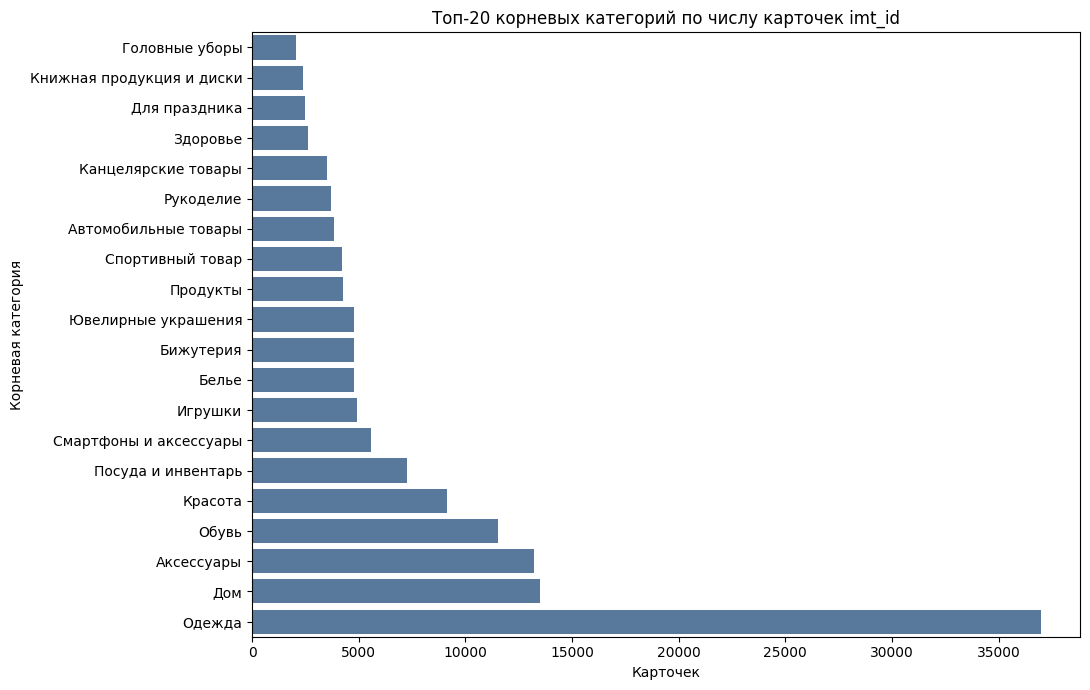

In [8]:
root_category_rows = df_raw["subj_root_name"].value_counts(dropna=False).rename("rows").to_frame()
root_category_imt = (
    df_raw.assign(subj_root_name=as_clean_string(df_raw["subj_root_name"])).dropna(subset=["subj_root_name"])
    .groupby("subj_root_name")["imt_id"].nunique().rename("unique_imt_id").sort_values(ascending=False).to_frame()
)
subj_category_imt = (
    df_raw.assign(subj_name=as_clean_string(df_raw["subj_name"])).dropna(subset=["subj_name"])
    .groupby("subj_name")["imt_id"].nunique().rename("unique_imt_id").sort_values(ascending=False)
)
display(root_category_rows.head(10))
display(pd.Series({"subject_categories": len(subj_category_imt), "subjects_with_one_card": int(subj_category_imt.eq(1).sum())}).to_frame("value"))

fig, ax = plt.subplots(figsize=(11, 7))
plot_data = root_category_imt.head(20).sort_values("unique_imt_id").reset_index()
sns.barplot(data=plot_data, y="subj_root_name", x="unique_imt_id", ax=ax, color="#4C78A8")
ax.set(title="Топ-20 корневых категорий по числу карточек imt_id", xlabel="Карточек", ylabel="Корневая категория")
fig.tight_layout()
plt.show()

**Вывод по `root_category_rows`, `root_category_imt` и графику.** Каталог неоднороден: крупнейшая корневая категория "Одежда" (43 316 строк) почти втрое больше следующих "Аксессуары" (16 446) и "Дом" (15 024); "Обувь" - 13 187 строк. Предметных категорий 3 233, из них 525 содержат одну карточку - для такого хвоста качество поиска и метрики будут неустойчивыми. MVP ограничиваем 1–3 корневыми категориями.

#### 2.4. Длины текстов

Длины названий и описаний в словах и символах понадобятся при выборе эмбеддера и политики обрезки.

count       mean         std  min    1%    5%  \
imt_name    characters  199292.0  32.968694     23.9208  1.0   4.0   5.0   
            words       199292.0   4.819215    3.637775  1.0   1.0   1.0   
description characters  142491.0  522.09096  485.182015  1.0  46.0  68.0   
            words       142491.0  70.720375   66.458342  1.0   6.0   9.0   

                          25%    50%    75%     95%     99%     max  
imt_name    characters    9.0   31.0   49.0    81.0    97.0   121.0  
            words         1.0    4.0    7.0    12.0    15.0    31.0  
description characters  195.0  398.0  731.5  1324.0  2353.0  5000.0  
            words        26.0   53.0   97.0   188.0   321.0   754.0

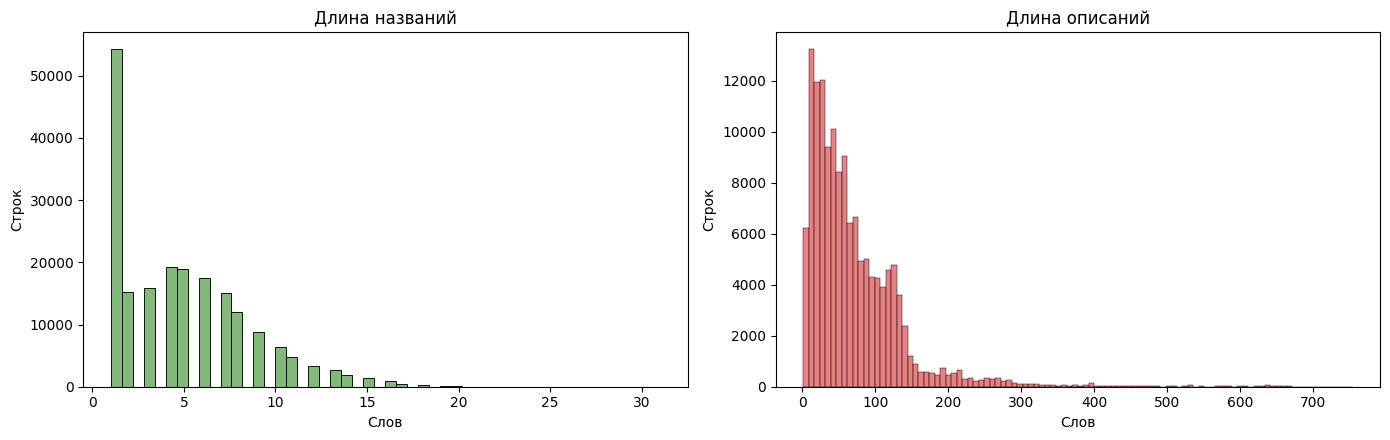

In [9]:
length_summary = pd.concat({"imt_name": text_length_profile(df_raw["imt_name"]), "description": text_length_profile(df_raw["description"])})
display(length_summary)

length_frame = pd.DataFrame({
    "imt_name_words": as_clean_string(df_raw["imt_name"]).str.findall(r"\S+").str.len(),
    "description_words": as_clean_string(df_raw["description"]).str.findall(r"\S+").str.len(),
}).apply(pd.to_numeric, errors="coerce")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(length_frame["imt_name_words"].dropna(), bins=50, ax=axes[0], color="#59A14F")
sns.histplot(length_frame["description_words"].dropna(), bins=100, ax=axes[1], color="#E15759")
axes[0].set(title="Длина названий", xlabel="Слов", ylabel="Строк")
axes[1].set(title="Длина описаний", xlabel="Слов", ylabel="Строк")
fig.tight_layout()
plt.show()

**Вывод по `length_summary` и гистограммам.** Названия короткие: медиана 4 слова (31 символ), 99% - не длиннее 15 слов. Описания в медиане 53 слова (398 символов), но у 5% длиннее 188 слов, у 1% - 321 слова, максимум 754 слова (5 000 символов). Длинный хвост описаний нужно сопоставить с лимитом токенов модели эмбеддингов: часть текста будет обрезаться.

#### 2.5. Ручная проверка карточек и текстовые артефакты

Смотрим 30 случайных карточек (фиксированный seed) и автоматические флаги: HTML в описаниях, спецсимволы и длинные буквенно-цифровые токены в названиях. Флаги сужают ручную проверку, но сами не являются правилом очистки.

In [ ]:
manual_columns = ["imt_id", "nm_id", "imt_name", "subj_root_name", "subj_name", "brand_name", "nm_colors_names", "description"]
manual_sample = df_raw[manual_columns].sample(n=30, random_state=SEED)
display(manual_sample[["imt_id", "imt_name", "subj_root_name", "subj_name", "brand_name"]])
display(HTML(manual_sample.iloc[[0, 4, 5]].to_html(index=False, escape=True)))

article_like = (r"(?i)\b(?=[a-zа-яё0-9_-]{6,}\b)(?=[a-zа-яё0-9_-]*\d)(?=[a-zа-яё0-9_-]*[a-zа-яё])[a-zа-яё0-9_-]+\b")
text_diagnostics = pd.DataFrame({
    "html_in_description": as_clean_string(df_raw["description"]).str.contains(r"<[^>]+>", regex=True, na=False),
    "special_symbols_in_name": as_clean_string(df_raw["imt_name"]).str.contains(r"[^\w\s.,;:!?()'\"""--]", regex=True, na=False),
    "article_like_token_in_name": as_clean_string(df_raw["imt_name"]).str.contains(article_like, regex=True, na=False),
})
display(text_diagnostics.agg(["sum", "mean"]).T.rename(columns={"sum": "count", "mean": "share"}).style.format({"share": "{:.2%}"}))
display(df_raw.loc[text_diagnostics["html_in_description"], ["imt_id", "imt_name", "description"]].head(5))

,imt_id,imt_name,subj_root_name,subj_name,brand_name
119737,10108023,Набор гель-блестки для тела с кисточкой,Красота,Глиттеры,LUKKY
72272,10064796,Пирсинг для пупка серебро 925 проба,Ювелирные украшения,Ювелирный пирсинг,RICH LINE
158154,10147294,Чехол на Samsung Galaxy M21 / M30s / M31,Смартфоны и аксессуары,Чехлы для телефонов,Kupicase
65426,10058577,Набор стикеров Аниме Naruto (Наруто),Канцелярские товары,Стикеры,FANDOM
30074,10027164,Контактные линзы Pure Vision 2 (6 линз) R 8.6 ...,Здоровье,Контактные линзы,Bausch+Lomb
23677,10021271,"Головка 1/2"" DR со вставкой TORX T70 длиной 10...",Строительные инструменты,Головки торцевые,Airline
134858,10126692,"Сумка для ноутбука 13.3"" с косметичкой",Аксессуары,Сумки для ноутбуков,skyka
176418,10163716,Чехол на XIAOMI 9T / Силиконовый Матовый Проти...,Смартфоны и аксессуары,Чехлы для телефонов,HaruCase
132467,10120372,Спортивные брюки,Одежда,Брюки,SCORE BOARD
4082,10003470,Чехол для телефона,Смартфоны и аксессуары,Чехлы для телефонов,Bee's Knees


imt_id,nm_id,imt_name,subj_root_name,subj_name,brand_name,nm_colors_names,description
10108023,6277206,Набор гель-блестки для тела с кисточкой,Красота,Глиттеры,LUKKY,"глубокий пурпурный, синий","Lucky набор гель-блестки д тела/лица х3 шт + кисточка, цвета: синий, серебро, пурпур, на блистере."
10027164,13388001,Контактные линзы Pure Vision 2 (6 линз) R 8.6 D -6.00,Здоровье,Контактные линзы,Bausch+Lomb,,"В этих одномесячных линзах идеально сочетаются высокая четкость зрения и гарантированный комфорт. Они идеально корригируют зрение с утра до самого вечера: даже в темное время Вы сможете ясно видеть все вокруг, а изображение будет четким и контрастным, избавленным от ореолов и бликов. Контактные линзы PureVision 2 HD необычайно тонки - всего 0,07 мм, а их края имеют немного закругленную форму - за счет этого линзы совершенно не чувствуются на глазах и незаметны даже для Вас самих. Кислородопроницаемость PureVision 2 HD довольно высока - на протяжении 24 часов они обеспечивают свободный доступ кислорода к поверхности глаза, поэтому носить их чрезвычайно комфортно и удобно."
10021271,13379371,"Головка 1/2"" DR со вставкой TORX T70 длиной 100мм (AT-BS-31)",Строительные инструменты,Головки торцевые,Airline,,"Инструменты соответствуют высоким стандартам качества, поэтому подойдут как для использования на бытовом уровне, так и для применения в профессиональной сфере.\nИнструменты изготовлены из высококачественной хром-ванадиевой стали. Металлические части изготовлены методом горячей ковки, что придаёт им высокую прочность и долговечность. Финишное прочное хромированное покрытие защищает Инструмент от воздействия коррозии, делает его более износостойким и легко очищается от загрязнений. Финишная обработка двух типов (частичная полировка) головок придаёт им отличный внешний вид."


,count,share
html_in_description,22.000000,0.01%
special_symbols_in_name,26546.000000,13.27%
article_like_token_in_name,14888.000000,7.44%


,imt_id,imt_name,description
1621,10001415,,Мужская сумка из прочного материала. Размер 35...
34955,10031525,шорты мужские спортивные летние,Шорты от немецкого бренда Yakuza Premium с при...
43837,10039293,Беспроводная клавиатура 890S,Клавиатура Оклик 890S характеризуется низкопро...
46116,10041293,Уксус бальзамический Premium Священное сусло 2...,"Состав: уваренное виноградное сусло, винный ук..."
51506,10045934,Евангельские события. Сергей Воробьев,"В книге Сергея Воробьева ""Великие события от Р..."


**Вывод по `manual_sample` и `text_diagnostics`.** Ручной просмотр 30 карточек показывает, что технические обозначения несут смысл (`R 8.6` у контактных линз `imt_id=10027164`, `TORX T70` у торцевой головки `imt_id=10021271`), поэтому удалять буквенно-цифровые токены нельзя. Многие названия предельно общие - "Костюм", "Куртка", "Платье", "Бермуды", - так что детали товара есть только в описании. HTML встречается редко (22 описания), спецсимволы - в 13,27% названий, длинные буквенно-цифровые токены - в 7,44%. План очистки: убрать HTML и управляющие символы, нормализовать пробелы, технические токены сохранить.

#### 2.6. Бренд и цвет

Оцениваем, часто ли цвет уже присутствует в названии (сравнение с учётом русских окончаний), чтобы решить, добавлять ли цвет и бренд в текст товара.

In [11]:
def color_mentioned_in_name(frame: pd.DataFrame) -> pd.Series:
    """Диагностика: встречается ли основа цвета из nm_colors_names в названии."""
    names = as_clean_string(frame["imt_name"]).str.lower()
    colors = as_clean_string(frame["nm_colors_names"]).str.lower()
    endings = ("ыми", "ими", "ого", "ему", "ому", "ая", "яя", "ое", "ее", "ой", "ый", "ий", "ые", "ие", "ых", "их", "ым", "им", "ую", "юю", "ом", "ем", "ам", "ям", "ах", "ях", "а", "я", "ы", "и", "у", "ю", "е", "о")

    def stem(token: str) -> str:
        token = token.replace("ё", "е")
        for ending in endings:
            if token.endswith(ending) and len(token) - len(ending) >= 4:
                return token[: -len(ending)]
        return token

    def overlaps(row):
        name, color_value = row
        if pd.isna(name) or pd.isna(color_value):
            return pd.NA
        name = name.replace("ё", "е")
        tokens = [t.strip() for t in re.split(r"[,/;]", color_value) if t.strip()]
        return any(re.search(rf"(?<!\w){re.escape(stem(t))}\w*(?!\w)", name) for t in tokens if len(stem(t)) >= 4)

    return pd.concat([names, colors], axis=1).apply(overlaps, axis=1).astype("boolean")


color_in_name = color_mentioned_in_name(df_raw)
attribute_summary = pd.Series({
    "unique_nonempty_brands": as_clean_string(df_raw["brand_name"]).nunique(),
    "rows_with_color": int(as_clean_string(df_raw["nm_colors_names"]).notna().sum()),
    "rows_with_name_and_color": int(color_in_name.notna().sum()),
    "color_found_in_name": int(color_in_name.fillna(False).sum()),
    "share_of_name_and_color_rows": float(color_in_name.mean()),
}).to_frame("value")
display(attribute_summary)

,value
unique_nonempty_brands,13318.000000
rows_with_color,165774.000000
rows_with_name_and_color,165130.000000
color_found_in_name,6506.000000
share_of_name_and_color_rows,0.039399


**Вывод по `attribute_summary`.** Брендов 13 318. Цвет указан у 165 774 строк, но в названии он встречается лишь у 6 506 из 165 130 строк с обоими полями (3,94%), то есть цвет почти не дублируется названием. Бренд - точный идентификатор, для брендовых запросов лучше подходит лексическое совпадение или фильтр. В базовый `product_text` бренд и цвет не включаем; это кандидаты для отдельной проверки.

#### 2.7. Тренировочная разметка

Только `queries_synthetic_train`: пары, шкала релевантности, число оценённых товаров на запрос и примеры запросов.

In [12]:
assert queries_train["relevance"].between(0, 3).all()
assert queries_train.groupby("query_id")["query_text"].nunique().eq(1).all()
items_per_query = queries_train.groupby("query_id")["item_id"].nunique().rename("rated_items_per_query")
query_inventory = pd.Series({
    "query_item_pairs": len(queries_train),
    "unique_query_id": queries_train["query_id"].nunique(),
    "unique_item_id": queries_train["item_id"].nunique(),
    "duplicate_query_item_pairs": int(queries_train.duplicated(["query_id", "item_id"]).sum()),
}).to_frame("value")
display(query_inventory)
display(items_per_query.describe(percentiles=[.05, .5, .95]).to_frame().T)
display(queries_train["relevance"].value_counts().sort_index().rename("pairs").to_frame().T)
display(queries_train[["query_id", "query_text"]].drop_duplicates().sample(n=10, random_state=SEED))

,value
query_item_pairs,11453
unique_query_id,700
unique_item_id,2285
duplicate_query_item_pairs,0


,count,mean,std,min,5%,50%,95%,max
rated_items_per_query,700.0,16.361429,5.42415,1.0,7.0,16.0,26.0,31.0


relevance,1,2,3
pairs,9652,1101,700


,query_id,query_text
2484,SYN_000210,топы cop copine
8139,SYN_000714,худи mego as
6376,SYN_000561,бриджи зуавы
2446,SYN_000206,кожаные мокасины
5214,SYN_000450,кожаные сабо с открытым мысом
3373,SYN_000286,классические джинсовые джинсы
3746,SYN_000318,шубы натуральные на пуговицах
4678,SYN_000401,тапочки asd
4852,SYN_000414,тапочки t taccardi
5737,SYN_000505,кигуруми londe


**Вывод по `query_inventory`, `items_per_query` и распределению `relevance`.** Train содержит 11 453 пары для 700 запросов и 2 285 товаров, повторов пар нет. На запрос в медиане 16 оценённых товаров (5% запросов - не больше 7). Оценки несбалансированы: 9 652 единицы, 1 101 двойка и 700 троек, нулей нет. Запросы короткие и составлены из типа товара и атрибута или бренда ("кожаные мокасины", "топы cop copine") - это задача query-to-item, а не поиск по тексту карточки. По разделу 1 все `item_id` train и test есть в каталоге, а запросы train и test не пересекаются ни по `query_id`, ни по тексту.

#### 2.8. Выбор категорий MVP и шаблона `product_text`

Для MVP берём до трёх корневых категорий. Правило ранжирования: число train-запросов, у которых есть релевантный (`relevance >= 2`) товар в категории, затем число карточек с текстом, затем название. Правило использует только train и сырой каталог.

In [13]:
RELEVANCE_THRESHOLD = 2
K_VALUES = (1, 3, 5, 10)


def select_mvp_root_categories(products: pd.DataFrame, queries: pd.DataFrame, relevance_threshold: int, top_n: int = 3) -> pd.DataFrame:
    lookup = products[["imt_id", "subj_root_name", "imt_name", "description"]].copy()
    lookup["subj_root_name"] = as_clean_string(lookup["subj_root_name"])
    indexable = as_clean_string(lookup["imt_name"]).notna() | as_clean_string(lookup["description"]).notna()
    catalog_size = lookup.loc[indexable & lookup["subj_root_name"].notna()].groupby("subj_root_name")["imt_id"].nunique().rename("indexable_imt_count")
    relevant = queries.loc[queries["relevance"] >= relevance_threshold, ["query_id", "item_id"]]
    joined = relevant.merge(lookup[["imt_id", "subj_root_name"]].drop_duplicates("imt_id"), left_on="item_id", right_on="imt_id", how="left")
    coverage = joined.dropna(subset=["subj_root_name"]).groupby("subj_root_name")["query_id"].nunique().rename("relevant_train_query_count")
    result = pd.concat([coverage, catalog_size], axis=1).fillna(0).reset_index()
    result["indexable_imt_count"] = result["indexable_imt_count"].astype(int)
    result = result.loc[result["relevant_train_query_count"] > 0]
    return (result.sort_values(["relevant_train_query_count", "indexable_imt_count", "subj_root_name"], ascending=[False, False, True], kind="stable")
            .head(top_n).reset_index(drop=True))


mvp_category_ranking = select_mvp_root_categories(df_raw, queries_train, RELEVANCE_THRESHOLD)
display(mvp_category_ranking)

PRODUCT_TEXT_VARIANTS = {
    "name_only": ["imt_name"],
    "name_and_subject": ["imt_name", "subj_name"],
    "name_subject_description": ["imt_name", "subj_name", "description"],
}
# Варианты сравниваем на одних и тех же карточках с заполненными обоими полями, чтобы разница длины шла только от шаблона.
strict_catalog = df_raw.loc[name_present & description_present]
option_rows = []
for variant, fields in PRODUCT_TEXT_VARIANTS.items():
    text = join_text_fields(strict_catalog, fields)
    words = text.str.findall(r"\S+").str.len().astype(float)
    assert not text.str.contains(ARTIFACT_PATTERN, case=False, regex=True).any()
    option_rows.append({"variant": variant, "fields": " . ".join(fields), "cards": len(text), "median_words": words.median(), "p95_words": words.quantile(.95)})
product_text_options = pd.DataFrame(option_rows)
display(product_text_options)

,subj_root_name,relevant_train_query_count,indexable_imt_count
0,Одежда,489.0,36854
1,Обувь,211.0,11522


,variant,fields,cards,median_words,p95_words
0,name_only,imt_name,141946,5.0,13.0
1,name_and_subject,imt_name . subj_name,141946,8.0,16.0
2,name_subject_description,imt_name . subj_name . description,141946,63.0,197.0


**Вывод по `mvp_category_ranking` и `product_text_options`.** Релевантные train-запросы есть только в двух корневых категориях: "Одежда" (489 запросов, 36 854 карточки с текстом) и "Обувь" (211 запросов, 11 522 карточки); остальные категории нельзя оценить на разметке, поэтому они не входят в MVP. На одних и тех же карточках шаблоны дают медиану/95-й перцентиль 5/13 слов (`imt_name`), 8/16 (`imt_name . subj_name`) и 63/197 (`imt_name . subj_name . description`). Выбираем полный шаблон: название часто не содержит деталей, `subj_name` явно задаёт тип товара, а описание - назначение и свойства; риск обрезки длинных описаний проверим на неделе 2.

**Решения недели 1:**

- уровень индексации - одна карточка на `imt_id`, так как поиск должен возвращать товар, а не его артикулы-варианты;
- из индекса исключаются только карточки без текста (пусты и `imt_name`, и `description`); карточки без описания остаются с текстом из названия и категории и помечаются признаком `has_description`, чтобы проверить качество поиска на них отдельно;
- категории MVP - "Одежда" и "Обувь";
- `product_text` = `imt_name . subj_name . description`; бренд и цвет в baseline не входят;
- очистка: удалить HTML-теги и управляющие символы, нормализовать пробелы, технические токены сохранить;
- порог бинаризации `relevance >= 2`, K = 1, 3, 5, 10, NDCG считается по исходной шкале 0–3.

---

## Неделя 2 - базовый пайплайн и оценка качества

**Цель:** на основе решений EDA создать работающий поиск и получить первые метрики. Простая модель на TF-IDF служит baseline - без этой точки отсчёта результат семантического поиска невозможно интерпретировать.

### 1. Подготовка данных

Реализуем решения недели 1:

1. Оставляем выбранные корневые категории.
2. Очищаем тексты: HTML-сущности и теги, управляющие символы, повторяющиеся пробелы. Технические токены (`TORX T70`, `100мм`) сохраняются - ручная проверка показала, что это смысловые характеристики.
3. Отбрасываем карточки, у которых после очистки пусты и `imt_name`, и `description`.
4. Дедуплицируем по `imt_id`. Правило: оставляем строку с самым длинным очищенным описанием, при равенстве - с меньшим `nm_id`, затем - первую в исходном файле. Так в индекс попадает самый информативный вариант карточки, а выбор детерминирован.
5. Собираем `product_text` = `imt_name . subj_name . description` (пустые поля пропускаются) и признак `has_description`.

In [14]:
MVP_ROOT_CATEGORIES = tuple(mvp_category_ranking["subj_root_name"])
CATALOG_COLUMNS = ["imt_id", "nm_id", "imt_name", "subj_name", "subj_root_name", "nm_colors_names", "vendor_code", "description", "brand_name"]
PRODUCT_TEXT_FIELDS = ["imt_name", "subj_name", "description"]


def clean_text(value: object) -> str:
    """Убирает разметку и управляющие символы, сохраняя технические обозначения."""
    if value is None or pd.isna(value):
        return ""
    text = unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_query(query: object) -> str:
    """Та же очистка для запросов и товаров плюс нижний регистр."""
    return clean_text(query).lower()


def prepare_catalog(products: pd.DataFrame, root_categories: Iterable[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    frame = products.loc[:, CATALOG_COLUMNS].copy()
    frame["source_row"] = np.arange(len(frame), dtype=np.int64)
    stages = [{"stage": "raw_rows", "rows": len(frame), "unique_imt_id": frame.imt_id.nunique()}]
    frame = frame.loc[frame.subj_root_name.isin(list(root_categories))].copy()
    stages.append({"stage": "selected_root_categories", "rows": len(frame), "unique_imt_id": frame.imt_id.nunique()})
    for column in CATALOG_COLUMNS[2:]:
        frame[column] = frame[column].map(clean_text)
    frame = frame.loc[frame.imt_name.ne("") | frame.description.ne("")].copy()
    stages.append({"stage": "has_name_or_description", "rows": len(frame), "unique_imt_id": frame.imt_id.nunique()})
    frame["description_length"] = frame.description.str.len()
    frame = frame.sort_values(["imt_id", "description_length", "nm_id", "source_row"], ascending=[True, False, True, True], kind="stable")
    catalog = frame.drop_duplicates("imt_id", keep="first").drop(columns="description_length").reset_index(drop=True)
    catalog["has_description"] = catalog.description.ne("")
    catalog["product_text"] = join_text_fields(catalog, PRODUCT_TEXT_FIELDS)
    stages.append({"stage": "deduplicated_imt_id", "rows": len(catalog), "unique_imt_id": catalog.imt_id.nunique()})
    return catalog, pd.DataFrame(stages)


full_catalog, catalog_stages = prepare_catalog(df_raw, MVP_ROOT_CATEGORIES)
assert full_catalog.imt_id.is_unique
assert full_catalog.product_text.ne("").all()
assert not full_catalog.product_text.str.contains(ARTIFACT_PATTERN, case=False, regex=True).any()
display(catalog_stages)
display(full_catalog.groupby("subj_root_name").agg(cards=("imt_id", "size"), without_description=("has_description", lambda s: int((~s).sum()))))

,stage,rows,unique_imt_id
0,raw_rows,200000,174427
1,selected_root_categories,56503,48489
2,has_name_or_description,56387,48376
3,deduplicated_imt_id,48376,48376


,cards,without_description
subj_root_name,,
Обувь,11522,7770
Одежда,36854,22519


Проверяем очистку вручную на 8 карточках, которые она изменила, и смотрим несколько итоговых `product_text`.

In [15]:
raw_view = df_raw.iloc[full_catalog.source_row.to_numpy()][["imt_name", "description"]].reset_index(drop=True)
changed = (raw_view.imt_name.fillna("").ne(full_catalog.imt_name) | raw_view.description.fillna("").ne(full_catalog.description))
cleaning_examples = pd.DataFrame({
    "imt_id": full_catalog.imt_id,
    "description_raw": raw_view.description.fillna("").str.slice(0, 160),
    "description_clean": full_catalog.description.str.slice(0, 160),
}).loc[changed].sample(n=8, random_state=SEED)
display(pd.Series({"cards_changed_by_cleaning": int(changed.sum()), "cards_total": len(full_catalog)}).to_frame("value"))
display(cleaning_examples)
display(full_catalog.sample(n=5, random_state=SEED)[["imt_id", "has_description", "product_text"]].assign(product_text=lambda d: d.product_text.str.slice(0, 200)))

,value
cards_changed_by_cleaning,5123
cards_total,48376


,imt_id,description_raw,description_clean
14378,10007318,MODEST FASHION.\nУдлиненный двубортный жакет п...,MODEST FASHION. Удлиненный двубортный жакет по...
22699,10046444,Майка женская выполнена из высококачественного...,Майка женская выполнена из высококачественного...
17120,10019033,LANETTI - это мужская обувь и сумки в стиле S...,LANETTI - это мужская обувь и сумки в стиле Sm...
18003,10024384,"Внимание!!! Уважаемые покупатели, модель малом...","Внимание!!! Уважаемые покупатели, модель малом..."
19754,10031090,"Легкое, приятное к телу платье с оригинальным ...","Легкое, приятное к телу платье с оригинальным ..."
41136,10144373,Пижама на мальчика - необходимая вещь в домашн...,Пижама на мальчика - необходимая вещь в домашн...
36781,10114516,Модное теплое платье для девочки с длинным рук...,Модное теплое платье для девочки с длинным рук...
33909,10100100,"Летняя куртка-ветровка ""оверсайз"" из плотной х...","Летняя куртка-ветровка ""оверсайз"" из плотной х..."


,imt_id,has_description,product_text
47215,10178223,True,Атласная женская блузка . Рубашки . Атласная б...
6467,1008592,False,Толстовка . Толстовки
43348,10154123,False,Босоножки . Босоножки
48236,10183931,False,Сандалии . Сандалии
15302,10012374,True,Сабо открытые пантолеты натуральная кожа на ни...


**Вывод по `catalog_stages`, `cleaning_examples`.** Из 200 000 строк в двух категориях 56 503 строки (48 489 карточек); текст есть у 56 387 строк; после дедупликации осталось 48 376 карточек `imt_id`. Очистка изменила 5 123 карточки (в примерах - переводы строк и лишние пробелы в описаниях). Описания нет у 22 519 из 36 854 карточек "Одежды" и у 7 770 из 11 522 карточек "Обуви", то есть у 62,6% каталога MVP: их текст сводится к виду "Толстовка . Толстовки". Это важный показатель качества каталога для бизнеса.

### 2. Модели поиска

Два движка с одинаковым интерфейсом `search_xxx(query, top_k) -> DataFrame` с колонками `rank, imt_id, score, imt_name, subj_name, description`. Это позволяет прогнать оба через одну функцию оценки.

- **Лексический baseline:** TF-IDF по `product_text`, униграммы и биграммы, словарь до 50 000 признаков, L2-нормализация; сходство - косинусное. Запрос проходит ту же очистку и приводится к нижнему регистру.
- **Семантический поиск:** `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (фиксированная ревизия) - компактная мультиязычная модель с поддержкой русского, 384 измерения. Товары кодируются батчами с `normalize_embeddings=True`, запрос - той же моделью тем же способом; поиск - полный перебор матричным умножением, чего достаточно для каталога из десятков тысяч товаров.

При равных score порядок определяется `imt_id`, поэтому выдача детерминирована.

In [16]:
RESULT_COLUMNS = ["rank", "imt_id", "score", "imt_name", "subj_name", "description"]
TFIDF_CONFIG = {"ngram_range": (1, 2), "max_features": 50_000, "lowercase": True, "norm": "l2"}
SEMANTIC_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
SEMANTIC_REVISION = "e8f8c211226b894fcb81acc59f3b34ba3efd5f42"
SEMANTIC_BATCH_SIZE = 32


def validate_top_k(top_k: int, catalog_size: int) -> int:
    if isinstance(top_k, bool) or not isinstance(top_k, (int, np.integer)) or top_k <= 0:
        raise ValueError("top_k must be a positive integer")
    return min(int(top_k), catalog_size)


def ranked_result(catalog: pd.DataFrame, scores: np.ndarray, top_k: int) -> pd.DataFrame:
    requested = validate_top_k(top_k, len(catalog))
    order = np.lexsort((catalog.imt_id.to_numpy(), -scores))[:requested]
    result = catalog.iloc[order][["imt_id", "imt_name", "subj_name", "description"]].copy()
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result.insert(2, "score", scores[order].astype(np.float32))
    return result[RESULT_COLUMNS].reset_index(drop=True)


def empty_result() -> pd.DataFrame:
    return pd.DataFrame({column: pd.Series(dtype="object") for column in RESULT_COLUMNS})


class LexicalSearch:
    def __init__(self, catalog: pd.DataFrame, vectorizer: TfidfVectorizer | None = None, matrix: sparse.csr_matrix | None = None):
        self.catalog = catalog.reset_index(drop=True)
        self.vectorizer = vectorizer or TfidfVectorizer(**TFIDF_CONFIG)
        self.matrix = matrix if matrix is not None else self.vectorizer.fit_transform(self.catalog.product_text.map(clean_query))
        assert self.matrix.shape[0] == len(self.catalog)

    def search(self, query: object, top_k: int = 10) -> pd.DataFrame:
        normalized = clean_query(query)
        if not normalized:
            return empty_result()
        scores = (self.matrix @ self.vectorizer.transform([normalized]).T).toarray().ravel()
        return ranked_result(self.catalog, scores, top_k)


class SemanticSearch:
    def __init__(self, catalog: pd.DataFrame, model: SentenceTransformer, embeddings: np.ndarray):
        self.catalog = catalog.reset_index(drop=True)
        self.model = model
        self.embeddings = np.asarray(embeddings, dtype=np.float32)
        assert self.embeddings.shape[0] == len(self.catalog)
        assert np.allclose(np.linalg.norm(self.embeddings, axis=1), 1, atol=1e-4)

    def encode_queries(self, queries: list[str]) -> np.ndarray:
        return self.model.encode([clean_query(q) for q in queries], batch_size=SEMANTIC_BATCH_SIZE, normalize_embeddings=True,
                                 convert_to_numpy=True, show_progress_bar=False).astype(np.float32)

    def search(self, query: object, top_k: int = 10) -> pd.DataFrame:
        if not clean_query(query):
            return empty_result()
        return ranked_result(self.catalog, self.embeddings @ self.encode_queries([query])[0], top_k)


def encode_products(model: SentenceTransformer, texts: pd.Series, cache_path: Path) -> np.ndarray:
    """Эмбеддинги товаров считаются батчами один раз и сохраняются в .npy вместе с хешем текстов."""
    digest = hashlib.sha256("\n".join(texts.map(clean_query)).encode("utf-8")).hexdigest()
    meta_path = cache_path.with_suffix(".json")
    if cache_path.exists() and meta_path.exists() and json.loads(meta_path.read_text())["texts_sha256"] == digest:
        return np.load(cache_path)
    embeddings = model.encode(texts.map(clean_query).tolist(), batch_size=SEMANTIC_BATCH_SIZE, normalize_embeddings=True,
                              convert_to_numpy=True, show_progress_bar=False).astype(np.float32)
    np.save(cache_path, embeddings)
    meta_path.write_text(json.dumps({"model": SEMANTIC_MODEL, "revision": SEMANTIC_REVISION, "texts_sha256": digest, "shape": list(embeddings.shape)}))
    return embeddings


def truncation_statistics(model: SentenceTransformer, texts: Iterable[str]) -> dict[str, float]:
    lengths = np.array([len(model.tokenizer(clean_query(t), add_special_tokens=True, truncation=False)["input_ids"]) for t in texts])
    return {"texts": len(lengths), "max_seq_length": int(model.max_seq_length), "median_tokens": float(np.median(lengths)),
            "p95_tokens": float(np.quantile(lengths, .95)), "truncated_share": float(np.mean(lengths > model.max_seq_length))}

In [17]:
embedding_model = SentenceTransformer(SEMANTIC_MODEL, revision=SEMANTIC_REVISION, device=DEVICE)
full_embeddings = encode_products(embedding_model, full_catalog.product_text, ARTIFACT_DIR / "full_catalog_embeddings.npy")

lexical_full = LexicalSearch(full_catalog)
semantic_full = SemanticSearch(full_catalog, embedding_model, full_embeddings)


def search_lexical(query: str, top_k: int = 10) -> pd.DataFrame:
    """TF-IDF-поиск по подготовленному каталогу MVP."""
    return lexical_full.search(query, top_k)


def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    """Поиск по эмбеддингам MiniLM по подготовленному каталогу MVP."""
    return semantic_full.search(query, top_k)


# Проверки контракта: пустой запрос, некорректный top_k, одинаковые колонки и ранги.
for engine in (search_lexical, search_semantic):
    assert engine("   ", 5).empty
    for invalid in (0, -1, 1.5, True):
        try:
            engine("кроссовки", invalid)
        except ValueError:
            pass
        else:
            raise AssertionError(f"invalid top_k accepted: {invalid!r}")
    result = engine("кожаные кроссовки", 5)
    assert result.columns.tolist() == RESULT_COLUMNS and result["rank"].tolist() == [1, 2, 3, 4, 5] and result.imt_id.is_unique

index_inventory = pd.DataFrame([
    {"index": "tfidf", "shape": str(lexical_full.matrix.shape), "vocabulary": len(lexical_full.vectorizer.vocabulary_)},
    {"index": "minilm", "shape": str(full_embeddings.shape), "vocabulary": None},
])
display(index_inventory)
query_texts = queries_train.drop_duplicates("query_id").query_text
display(pd.DataFrame({"products": truncation_statistics(embedding_model, full_catalog.product_text),
                      "train_queries": truncation_statistics(embedding_model, query_texts)}).T)

,index,shape,vocabulary
0,tfidf,"(48376, 50000)",50000.0
1,minilm,"(48376, 384)",NaN


,texts,max_seq_length,median_tokens,p95_tokens,truncated_share
products,48376.0,128.0,12.0,235.0,0.127377
train_queries,700.0,128.0,8.0,12.0,0.000000


**Вывод по `index_inventory` и статистике усечения.** Для всех 48 376 карточек построены TF-IDF-матрица 48 376×50 000 и эмбеддинги 48 376×384. Лимит модели - 128 токенов: у товаров медиана 12 токенов (много коротких карточек без описания), 95-й перцентиль - 235, обрезается 12,7% текстов; запросы короткие (медиана 8 токенов) и не обрезаются.

Проверяем обе модели вручную: 3 случайных train-запроса, по 5 ближайших товаров от каждого движка.

In [18]:
manual_queries = queries_train.drop_duplicates("query_id").sample(n=3, random_state=SEED).query_text.tolist()
manual_rows = []
for query in manual_queries:
    for method, engine in (("lexical", search_lexical), ("semantic", search_semantic)):
        manual_rows.append(engine(query, 5).assign(query=query, method=method))
manual_top5 = pd.concat(manual_rows, ignore_index=True)[["query", "method", "rank", "imt_name", "subj_name", "score"]]
display(manual_top5)

,query,method,rank,imt_name,subj_name,score
0,топы cop copine,lexical,1,Платье,Топы,0.864596
1,топы cop copine,lexical,2,Футболка,Топы,0.848141
2,топы cop copine,lexical,3,Топы,Топы,0.767012
3,топы cop copine,lexical,4,Топы,Топы,0.767012
4,топы cop copine,lexical,5,Топы,Топы,0.767012
5,топы cop copine,semantic,1,Костюм Казаки разбойники,Костюмы,0.627842
6,топы cop copine,semantic,2,Кардиган,Жакеты,0.608617
7,топы cop copine,semantic,3,Бомбер,Жакеты,0.598744
8,топы cop copine,semantic,4,Джемпер,Кофты,0.592842
9,топы cop copine,semantic,5,Джемпер,Кофты,0.592842


**Наблюдение по `manual_top5`.** На запросе "топы cop copine" TF-IDF возвращает товары категории "Топы", а MiniLM - костюм, кардиган, бомбер и джемперы, то есть теряет тип товара, когда в запросе есть незнакомый бренд. На "худи mego as" и "бриджи зуавы" оба подхода возвращают товары нужного типа. Грубых ошибок интерфейса нет, но семантический поиск заметно хуже удерживает тип товара.

### 3. Оценка качества решений

Метрики: Precision@K, Recall@K, MRR, NDCG@K, HitRate@K при K = 1, 3, 5, 10.

1. **Порог бинаризации** `RELEVANCE_THRESHOLD = 2` задан параметром. Оценка 1 означает лишь частичное соответствие, поэтому релевантными для бинарных метрик считаются оценки 2 и 3; оценка 3 есть у каждого запроса train (см. раздел 2.7), так что порог не оставляет запросы без релевантных товаров.
2. **NDCG** считается по полной шкале 0–3 с `gain = 2^rel - 1`; идеальная выдача (IDCG) строится по всей разметке запроса.
3. **Неразмеченные товары** в выдаче считаются нерелевантными (`relevance_map.get(item_id, 0)`); Recall считается от всех размеченных релевантных товаров запроса.
4. **Поиск идёт по всему каталогу**, а не по размеченным кандидатам.

**Golden-сет** строим только из `queries_synthetic_train`: запросы делим на development (80%) и validation (20%) с группировкой по нормализованному тексту, чтобы один текст не попал в обе части. Validation - golden-сет для сравнения всех конфигураций; development - для подбора параметров и обучения в экспериментах недели 3.

In [19]:
def dcg(relevances: list[int]) -> float:
    return float(sum((2 ** rel - 1) / math.log2(position + 2) for position, rel in enumerate(relevances)))


def query_metrics(ranked_ids: list[int], labels: dict[int, int], catalog_ids: set[int],
                  k_values: tuple[int, ...] = K_VALUES, threshold: int = RELEVANCE_THRESHOLD) -> dict[str, float]:
    relevant = {item for item, rel in labels.items() if rel >= threshold}
    ranked_relevance = [int(labels.get(item, 0)) for item in ranked_ids]
    first_hit = next((rank + 1 for rank, rel in enumerate(ranked_relevance) if rel >= threshold), None)
    result = {"mrr": 0.0 if first_hit is None else 1.0 / first_hit}
    ideal_dcg = {k: dcg(sorted(labels.values(), reverse=True)[:k]) for k in k_values}
    for k in k_values:
        hits = sum(rel >= threshold for rel in ranked_relevance[:k])
        result[f"precision_at_{k}"] = hits / k
        result[f"recall_at_{k}"] = hits / len(relevant) if relevant else 0.0
        result[f"hit_rate_at_{k}"] = float(hits > 0)
        result[f"ndcg_at_{k}"] = dcg(ranked_relevance[:k]) / ideal_dcg[k] if ideal_dcg[k] else 0.0
    full_ideal_10 = dcg(sorted(labels.values(), reverse=True)[:10])
    reachable_ideal_10 = dcg(sorted((rel for item, rel in labels.items() if item in catalog_ids), reverse=True)[:10])
    result["relevant_items"] = float(len(relevant))
    result["reachable_relevant_share"] = len(relevant & catalog_ids) / len(relevant) if relevant else 0.0
    result["ndcg_upper_bound_at_10"] = reachable_ideal_10 / full_ideal_10 if full_ideal_10 else 0.0
    result["labeled_share_at_10"] = float(np.mean([item in labels for item in ranked_ids[:10]])) if ranked_ids else 0.0
    return result


def evaluate_search(search: Callable[[object, int], pd.DataFrame], golden: pd.DataFrame, catalog_ids: pd.Series,
                    method: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Прогоняет каждый запрос golden-сета через поиск по всему каталогу и считает метрики по запросу."""
    depth = len(catalog_ids)  # полная выдача: MRR учитывает первый релевантный товар на любой позиции
    labels = golden.groupby("query_id").apply(lambda part: dict(zip(part.item_id.astype(int), part.relevance.astype(int))), include_groups=False)
    texts = golden.groupby("query_id").query_text.first()
    catalog_id_set = set(catalog_ids.astype(int))
    metric_rows, top_rows = [], []
    for query_id, query_text in texts.items():
        result = search(query_text, depth)
        metrics = query_metrics(result.imt_id.astype(int).tolist(), labels.loc[query_id], catalog_id_set)
        metric_rows.append({"method": method, "query_id": query_id, "query_text": query_text, **metrics})
        top = result.head(10).assign(query_id=query_id, query_text=query_text, method=method)
        top["relevance"] = top.imt_id.map(labels.loc[query_id]).fillna(0).astype(int)
        top_rows.append(top)
    return pd.DataFrame(metric_rows), pd.concat(top_rows, ignore_index=True)


METRIC_COLUMNS = ["mrr"] + [f"{m}_at_{k}" for m in ("precision", "recall", "ndcg", "hit_rate") for k in K_VALUES]


def summarize_metrics(per_query: pd.DataFrame) -> pd.DataFrame:
    return per_query.groupby("method", sort=False)[METRIC_COLUMNS].mean().reset_index()


# Контрольные сценарии для формул метрик.
perfect = query_metrics([1, 2, 3], {1: 3, 2: 2}, {1, 2, 3})
reversed_rank = query_metrics([3, 2, 1], {1: 3, 2: 2}, {1, 2, 3})
unrated_first = query_metrics([3, 1, 2], {1: 3, 2: 2}, {1, 2, 3})
no_relevant = query_metrics([1, 2], {1: 1}, {1, 2})
assert perfect["ndcg_at_3"] == 1 and perfect["mrr"] == 1 and perfect["recall_at_3"] == 1
assert reversed_rank["ndcg_at_3"] < 1 and reversed_rank["mrr"] == 0.5
assert unrated_first["precision_at_1"] == 0 and unrated_first["mrr"] == 0.5
assert no_relevant["recall_at_10"] == 0 and no_relevant["mrr"] == 0
display(pd.DataFrame([perfect, reversed_rank, unrated_first, no_relevant], index=["perfect", "reversed", "unrated_first", "no_relevant"])
        [["precision_at_1", "recall_at_3", "mrr", "ndcg_at_3"]])

,precision_at_1,recall_at_3,mrr,ndcg_at_3
perfect,1.0,1.0,1.0,1.000000
reversed,0.0,1.0,0.5,0.606423
unrated_first,0.0,1.0,0.5,0.665315
no_relevant,0.0,0.0,0.0,1.000000


In [20]:
def split_queries(queries: pd.DataFrame, seed: int) -> pd.DataFrame:
    table = queries[["query_id", "query_text"]].drop_duplicates("query_id").copy()
    table["normalized_query_text"] = table.query_text.map(clean_query)
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    _, val_index = next(splitter.split(table, groups=table.normalized_query_text))
    table["split"] = "development"
    table.iloc[val_index, table.columns.get_loc("split")] = "validation"
    return table.sort_values("query_id").reset_index(drop=True)


query_split = split_queries(queries_train, SEED)
dev_ids = set(query_split.loc[query_split.split.eq("development"), "query_id"])
val_ids = set(query_split.loc[query_split.split.eq("validation"), "query_id"])
development = queries_train.loc[queries_train.query_id.isin(dev_ids)].sort_values(["query_id", "item_id"]).reset_index(drop=True)
golden = queries_train.loc[queries_train.query_id.isin(val_ids)].sort_values(["query_id", "item_id"]).reset_index(drop=True)

assert dev_ids.isdisjoint(val_ids) and len(dev_ids | val_ids) == queries_train.query_id.nunique()
assert set(query_split.loc[query_split.split.eq("development"), "normalized_query_text"]).isdisjoint(
    set(query_split.loc[query_split.split.eq("validation"), "normalized_query_text"]))
display(query_split.split.value_counts().rename("queries").to_frame().T)
display(golden.relevance.value_counts().sort_index().rename("golden_pairs").to_frame().T)

split,development,validation
queries,560,140


relevance,1,2,3
golden_pairs,1960,181,140


**Вывод по разбиению.** Разбиение дало 560 development- и 140 validation-запросов; нормализованные тексты не пересекаются (assertion выполнен). Golden-сет - 2 281 пара validation: 1 960 оценок 1, 181 оценка 2 и 140 оценок 3.

### 4. Каталог для поиска и оценки

Разметка делалась асессорами по ограниченному пулу товаров. Проверяем, как это влияет на метрики:

1. Считаем NDCG@10 лексического поиска по всему подготовленному каталогу на 100 development-запросах.
2. Выводим топ-10 для одного запроса и отмечаем, какие товары есть в разметке.
3. Ограничиваем каталог оценки пулом асессоров: берём из `wb_products_dedup.parquet` только список `imt_id` и оставляем пересечение с подготовленным каталогом (тексты и признаки - наши, из раздела 1).
4. Пересчитываем метрику на тех же запросах и сравниваем.
5. Смотрим распределение `relevance` и число оценённых товаров на запрос; проверяем, у всех ли запросов есть товары с `relevance >= 2`.

In [21]:
probe_queries = development.loc[development.query_id.isin(
    pd.Series(sorted(dev_ids)).sample(n=100, random_state=SEED))].reset_index(drop=True)
probe_full, probe_full_top10 = evaluate_search(search_lexical, probe_queries, full_catalog.imt_id, "lexical_full_catalog")
display(summarize_metrics(probe_full)[["method", "ndcg_at_10", "mrr", "hit_rate_at_10"]]
        .assign(catalog_size=len(full_catalog), labeled_share_at_10=probe_full.labeled_share_at_10.mean()))

example_query_id = probe_full.sort_values(["labeled_share_at_10", "query_id"]).query_id.iloc[0]
example_top10 = probe_full_top10.loc[probe_full_top10.query_id.eq(example_query_id)].copy()
example_labels = probe_queries.loc[probe_queries.query_id.eq(example_query_id)].set_index("item_id").relevance
example_top10["in_markup"] = example_top10.imt_id.isin(example_labels.index)
display(example_top10[["query_text", "rank", "imt_id", "imt_name", "subj_name", "in_markup", "relevance"]])

,method,ndcg_at_10,mrr,hit_rate_at_10,catalog_size,labeled_share_at_10
0,lexical_full_catalog,0.090196,0.072076,0.12,48376,0.135


,query_text,rank,imt_id,imt_name,subj_name,in_markup,relevance
120,молочные хлопковые крестильные платья,1,10079758,Брюки хлопковые,Брюки,False,0
121,молочные хлопковые крестильные платья,2,10085595,Плятье,Платья,False,0
122,молочные хлопковые крестильные платья,3,10141834,"""Паула""",Платья,False,0
123,молочные хлопковые крестильные платья,4,10142980,Платьелетнее/платьелето2020/платьешифон/платье...,Платья,False,0
124,молочные хлопковые крестильные платья,5,10146770,Платьте,Платья,False,0
125,молочные хлопковые крестильные платья,6,10079759,Брюки легкие хлопковые,Брюки,False,0
126,молочные хлопковые крестильные платья,7,10079762,Брюки,Брюки,False,0
127,молочные хлопковые крестильные платья,8,10010938,Платья с шортами,Платья,False,0
128,молочные хлопковые крестильные платья,9,101408,Платье Blend,Платья,False,0
129,молочные хлопковые крестильные платья,10,10001024,Платье Дженифер,Платья,False,0


**Наблюдение по `probe_full` и `example_top10`.** По всему каталогу MVP (48 376 карточек) на 100 development-запросах TF-IDF получает NDCG@10 = 0,090, MRR = 0,072 и HitRate@10 = 0,12, при этом в разметке есть лишь 13,5% товаров из топ-10. На запросе "молочные хлопковые крестильные платья" в разметке нет ни одного из 10 найденных товаров (платья и хлопковые брюки), и все они считаются нерелевантными. Проблема не в поиске, а в оценке: асессоры размечали ограниченный пул, и поиск по всему каталогу наказывается за неразмеченные товары.

In [22]:
assessed_ids = pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"]
assert assessed_ids.notna().all()
catalog = full_catalog.loc[full_catalog.imt_id.isin(set(assessed_ids.astype(int)))].reset_index(drop=True)
catalog_positions = full_catalog.reset_index().set_index("imt_id").loc[catalog.imt_id, "index"].to_numpy()
assert catalog.imt_id.is_unique

lexical = LexicalSearch(catalog)
semantic = SemanticSearch(catalog, embedding_model, full_embeddings[catalog_positions])

probe_pool, _ = evaluate_search(lexical.search, probe_queries, catalog.imt_id, "lexical_assessed_pool")
catalog_comparison = pd.concat([probe_full, probe_pool]).groupby("method", sort=False).agg(
    ndcg_at_10=("ndcg_at_10", "mean"), mrr=("mrr", "mean"), hit_rate_at_10=("hit_rate_at_10", "mean"),
    labeled_share_at_10=("labeled_share_at_10", "mean"), reachable_relevant_share=("reachable_relevant_share", "mean"))
catalog_comparison.insert(0, "catalog_size", [len(full_catalog), len(catalog)])
display(pd.Series({"assessed_pool_ids": assessed_ids.nunique(), "pool_in_prepared_catalog": len(catalog),
                   "pool_without_description": int((~catalog.has_description).sum())}).to_frame("value"))
display(catalog_comparison)

rated_per_query = queries_train.groupby("query_id").agg(rated_items=("item_id", "nunique"), relevant_items=("relevance", lambda r: int((r >= RELEVANCE_THRESHOLD).sum())))
display(rated_per_query.describe(percentiles=[.05, .5, .95]).T)
display(pd.Series({"queries": len(rated_per_query), "queries_without_relevant": int(rated_per_query.relevant_items.eq(0).sum())}).to_frame("value"))

,value
assessed_pool_ids,4256
pool_in_prepared_catalog,4256
pool_without_description,957


,catalog_size,ndcg_at_10,mrr,hit_rate_at_10,labeled_share_at_10,reachable_relevant_share
method,,,,,,
lexical_full_catalog,48376,0.090196,0.072076,0.12,0.135,1.0
lexical_assessed_pool,4256,0.441874,0.190929,0.50,0.836,1.0


,count,mean,std,min,5%,50%,95%,max
rated_items,700.0,16.361429,5.424150,1.0,7.0,16.0,26.0,31.0
relevant_items,700.0,2.572857,2.465001,1.0,1.0,1.0,8.0,17.0


,value
queries,700
queries_without_relevant,0


**Вывод по `catalog_comparison` и `rated_per_query`.** Все 4 256 карточек пула асессоров есть в подготовленном каталоге (957 из них без описания). На тех же 100 запросах по пулу NDCG@10 = 0,442, MRR = 0,191, HitRate@10 = 0,50, а доля размеченных товаров в топ-10 выросла до 83,6%. Поэтому дальнейшее сравнение ведём по каталогу пула. У всех 700 запросов есть хотя бы один товар с `relevance >= 2`; в медиане такой товар один (у 5% запросов - 8 и больше), поэтому Precision@K ограничен сверху самой разметкой.

Дальше все подходы оцениваются по одному каталогу `catalog` (пересечение подготовленного каталога с пулом асессоров); эмбеддинги для него - это строки уже посчитанной матрицы `full_embeddings`, модель и тексты те же.

### 5. Сравнение baseline на golden-сете

Оба подхода ищут по всему каталогу оценки на validation-запросах с одинаковыми порогом и K.

In [23]:
lexical_per_query, lexical_top10 = evaluate_search(lexical.search, golden, catalog.imt_id, "lexical_tfidf")
semantic_per_query, semantic_top10 = evaluate_search(semantic.search, golden, catalog.imt_id, "semantic_minilm_full_text")
baseline_summary = summarize_metrics(pd.concat([lexical_per_query, semantic_per_query]))
display(baseline_summary.set_index("method").T.style.format("{:.3f}"))
display(pd.concat([lexical_per_query, semantic_per_query]).groupby("method", sort=False)[
    ["reachable_relevant_share", "ndcg_upper_bound_at_10", "labeled_share_at_10"]].mean())

method,lexical_tfidf,semantic_minilm_full_text
mrr,0.169,0.117
precision_at_1,0.071,0.050
precision_at_3,0.062,0.055
precision_at_5,0.063,0.049
precision_at_10,0.070,0.041
recall_at_1,0.041,0.023
recall_at_3,0.101,0.067
recall_at_5,0.165,0.099
recall_at_10,0.320,0.171
ndcg_at_1,0.191,0.114


,reachable_relevant_share,ndcg_upper_bound_at_10,labeled_share_at_10
method,,,
lexical_tfidf,1.0,1.0,0.854286
semantic_minilm_full_text,1.0,1.0,0.398571


**Вывод по `baseline_summary`.** Лексический поиск выигрывает у семантического по всем метрикам и при всех K: NDCG@10 - 0,459 против 0,231, MRR - 0,169 против 0,117, Recall@10 - 0,320 против 0,171, HitRate@10 - 0,450 против 0,257, NDCG@1 - 0,191 против 0,114. Все релевантные товары golden-сета есть в каталоге (`reachable_relevant_share` = 1, верхняя граница NDCG@10 = 1). Семантический поиск чаще выдаёт неразмеченные товары (размечено 39,9% его топ-10 против 85,4% у TF-IDF), поэтому часть его "ошибок" может оказаться неоценёнными подходящими товарами - это ограничение оценки, а не доказательство качества. Низкие Precision@K ожидаемы: у запроса в медиане один релевантный товар.

Проверяем, как поиск ведёт себя на товарах без описания: (1) для каждого релевантного (`relevance >= 2`) товара golden-сета смотрим, попал ли он в топ-10, отдельно для карточек с описанием и без; (2) сравниваем долю карточек без описания в каталоге и на верхних позициях выдачи.

In [24]:
def recall_by_description(top10: pd.DataFrame, golden_pairs: pd.DataFrame) -> pd.DataFrame:
    relevant = golden_pairs.loc[golden_pairs.relevance >= RELEVANCE_THRESHOLD].merge(
        catalog[["imt_id", "has_description"]], left_on="item_id", right_on="imt_id", how="inner")
    found = set(zip(top10.query_id, top10.imt_id))
    relevant["found_in_top10"] = [(q, i) in found for q, i in zip(relevant.query_id, relevant.item_id)]
    return (relevant.groupby("has_description").agg(relevant_pairs=("found_in_top10", "size"), recall_at_10=("found_in_top10", "mean"))
            .reindex([True, False]).fillna({"relevant_pairs": 0}))


description_effect = pd.concat({"lexical_tfidf": recall_by_description(lexical_top10, golden),
                                "semantic_minilm_full_text": recall_by_description(semantic_top10, golden)})
display(description_effect)


def no_description_share(top10: pd.DataFrame, max_rank: int) -> float:
    top = top10.loc[top10["rank"] <= max_rank, ["imt_id"]].merge(catalog[["imt_id", "has_description"]], on="imt_id")
    return float((~top.has_description).mean())


position_bias = pd.DataFrame({
    method: {"share_in_catalog": float((~catalog.has_description).mean()),
             "share_at_rank_1": no_description_share(top10, 1),
             "share_in_top10": no_description_share(top10, 10)}
    for method, top10 in (("lexical_tfidf", lexical_top10), ("semantic_minilm_full_text", semantic_top10))
}).T
display(position_bias.style.format("{:.1%}"))

relevant_pairs  recall_at_10
                          has_description                              
lexical_tfidf             True                      321.0      0.305296
                          False                       0.0           NaN
semantic_minilm_full_text True                      321.0      0.177570
                          False                       0.0           NaN

,share_in_catalog,share_at_rank_1,share_in_top10
lexical_tfidf,22.5%,90.7%,70.8%
semantic_minilm_full_text,22.5%,83.6%,76.6%


**Вывод по `description_effect` и `position_bias`.** Все 321 релевантная пара golden-сета - карточки с описанием; среди карточек без описания релевантных нет. При этом карточки без описания составляют 22,5% каталога, но занимают 90,7% первых позиций у TF-IDF и 83,6% у MiniLM (70,8% и 76,6% топ-10). Короткий текст вида "Полуботинки . Полуботинки" почти целиком совпадает с коротким запросом и вытесняет подробные карточки. Это главная причина низких P@1 и MRR обоих подходов и кандидат на доработку.

Разбор ошибок: три validation-запроса с наибольшей разницей NDCG@10 между подходами, их топ-10 и разметка.

In [25]:
ndcg_gap = (pd.concat([lexical_per_query, semantic_per_query])
            .pivot(index=["query_id", "query_text"], columns="method", values="ndcg_at_10").reset_index())
ndcg_gap["semantic_minus_lexical"] = ndcg_gap.semantic_minilm_full_text - ndcg_gap.lexical_tfidf
error_queries = ndcg_gap.reindex(ndcg_gap.semantic_minus_lexical.abs().sort_values(ascending=False).index).head(3)
display(error_queries)
error_top = pd.concat([lexical_top10, semantic_top10]).merge(error_queries[["query_id"]], on="query_id")
display(error_top.loc[error_top["rank"] <= 5, ["query_text", "method", "rank", "imt_name", "subj_name", "relevance"]])

method,query_id,query_text,lexical_tfidf,semantic_minilm_full_text,semantic_minus_lexical
24,SYN_000156,шубы искусственные с капюшоном,0.954455,0.000000,-0.954455
29,SYN_000195,босоножки deezee,0.972584,0.108957,-0.863626
122,SYN_000885,детские полуботинки,0.879001,0.123344,-0.755657


,query_text,method,rank,imt_name,subj_name,relevance
0,шубы искусственные с капюшоном,lexical_tfidf,1,Шубы искусственные,Шубы искусственные,3
1,шубы искусственные с капюшоном,lexical_tfidf,2,Шубы натуральные,Шубы натуральные,0
2,шубы искусственные с капюшоном,lexical_tfidf,3,Шуба из искусственного меха/чебурашка/Искусств...,Шубы искусственные,1
3,шубы искусственные с капюшоном,lexical_tfidf,4,Шуба,Шубы натуральные,0
4,шубы искусственные с капюшоном,lexical_tfidf,5,Шуба нутрия,Шубы натуральные,0
10,босоножки deezee,lexical_tfidf,1,Босоножки,Босоножки,3
11,босоножки deezee,lexical_tfidf,2,Босоножки 4170,Босоножки,1
12,босоножки deezee,lexical_tfidf,3,Босоножки MT707,Босоножки,1
13,босоножки deezee,lexical_tfidf,4,Босоножки 509,Босоножки,1
14,босоножки deezee,lexical_tfidf,5,Босоножки 610,Босоножки,1


**Вывод по `error_queries` и `error_top`.** В трёх запросах с наибольшим расхождением - "шубы искусственные с капюшоном", "босоножки deezee", "детские полуботинки" - TF-IDF ставит товар с оценкой 3 на первое место (совпадение по типу товара), а MiniLM возвращает товары других типов: кофточки и тапочки вместо шуб, дутики и сабо вместо босоножек, кроссовки вместо полуботинок. Семантическая модель путает смежные категории обуви и одежды и не удерживает тип товара, который пользователь назвал явно.

**Итоги недели 2.** Baseline - TF-IDF: на golden-сете он вдвое лучше MiniLM по NDCG@10. Семантический поиск в исходном виде не заменяет лексический. Гипотезы для недели 3: (1) короткий `product_text` уберёт обрезку длинных описаний; (2) гибрид сохранит точные совпадения TF-IDF и добавит находки семантики; (3) дообучение на парах из train адаптирует эмбеддинги к домену. Открытый риск - перекос выдачи в сторону карточек без описания.

---

## Неделя 3 - эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы об улучшении поиска, выбрать конфигурацию на validation, один раз проверить её на test и дать рекомендации бизнесу.

**Главное правило:** один эксперимент - одна гипотеза - одно изменение относительно baseline. Все конфигурации оцениваются на одном golden-сете (`golden`, validation), с одним каталогом, порогом и K. Подбор параметров и обучение используют только development-запросы.

In [26]:
def frame_fingerprint(frame: pd.DataFrame, columns: list[str]) -> str:
    return hashlib.sha256(frame[columns].to_csv(index=False, lineterminator="\n").encode("utf-8")).hexdigest()[:16]


PROTOCOL = {
    "seed": SEED,
    "k_values": K_VALUES,
    "relevance_threshold": RELEVANCE_THRESHOLD,
    "catalog_size": len(catalog),
    "catalog_fingerprint": frame_fingerprint(catalog, ["imt_id", "product_text"]),
    "golden_fingerprint": frame_fingerprint(golden, ["query_id", "item_id", "relevance"]),
    "development_queries": development.query_id.nunique(),
    "validation_queries": golden.query_id.nunique(),
}
EXPERIMENT_DIR = ARTIFACT_DIR / "experiments"
EXPERIMENT_DIR.mkdir(exist_ok=True)
golden_copy_path = EXPERIMENT_DIR / "golden_validation.parquet"
golden.to_parquet(golden_copy_path, index=False)

# Результаты всех конфигураций на validation: method -> (per_query, top10, params)
results = {
    "lexical_tfidf": (lexical_per_query, lexical_top10, {"approach": "lexical", "model": "tfidf", "product_text": "imt_name . subj_name . description",
                                                         "tfidf_ngram_range": "(1, 2)", "tfidf_max_features": 50_000}),
    "semantic_minilm_full_text": (semantic_per_query, semantic_top10, {"approach": "semantic", "model": SEMANTIC_MODEL, "model_revision": SEMANTIC_REVISION,
                                                                       "product_text": "imt_name . subj_name . description"}),
}
display(pd.Series(PROTOCOL).to_frame("value"))

,value
seed,42
k_values,"(1, 3, 5, 10)"
relevance_threshold,2
catalog_size,4256
catalog_fingerprint,8fd5dc3a91660139
golden_fingerprint,9a36bd9a8e3418bd
development_queries,560
validation_queries,140


### 1. Эксперименты по улучшению

#### Эксперимент 1 - короткий текст товара для эмбеддингов

- **Гипотеза.** Модель MiniLM имеет лимит 128 токенов, и заметная доля полных текстов товаров его превышает (раздел 2 недели 2), поэтому хвост описания обрезается, а вектор размывается длинными описаниями. Шаблон `imt_name . subj_name` целиком помещается в лимит и сохраняет смысловое ядро (название и тип товара), что должно улучшить семантическое ранжирование.
- **Что меняется.** Только шаблон `product_text` для эмбеддингов товаров; модель, запросы, каталог и протокол - как в семантическом baseline.

In [27]:
short_catalog = catalog.copy()
short_catalog["product_text"] = join_text_fields(short_catalog, ["imt_name", "subj_name"])
short_embeddings = encode_products(embedding_model, short_catalog.product_text, EXPERIMENT_DIR / "short_text_embeddings.npy")
semantic_short = SemanticSearch(short_catalog, embedding_model, short_embeddings)

short_per_query, short_top10 = evaluate_search(semantic_short.search, golden, catalog.imt_id, "semantic_minilm_short_text")
results["semantic_minilm_short_text"] = (short_per_query, short_top10, {"approach": "semantic", "model": SEMANTIC_MODEL, "model_revision": SEMANTIC_REVISION,
                                                                        "product_text": "imt_name . subj_name"})
display(pd.DataFrame({"full_text": truncation_statistics(embedding_model, catalog.product_text),
                      "short_text": truncation_statistics(embedding_model, short_catalog.product_text)}).T)
display(summarize_metrics(pd.concat([semantic_per_query, short_per_query])).set_index("method")[["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5", "hit_rate_at_10"]])

,texts,max_seq_length,median_tokens,p95_tokens,truncated_share
full_text,4256.0,128.0,77.0,300.0,0.275846
short_text,4256.0,128.0,12.0,27.0,0.000000


,ndcg_at_10,mrr,recall_at_10,precision_at_5,hit_rate_at_10
method,,,,,
semantic_minilm_full_text,0.230605,0.116813,0.171171,0.048571,0.257143
semantic_minilm_short_text,0.187718,0.144470,0.214055,0.062857,0.285714


- **Результат и вывод.** Короткий текст полностью убрал обрезку (доля обрезанных текстов пула: 27,6% → 0%). NDCG@10 снизился с 0,231 до 0,188, при этом MRR вырос с 0,117 до 0,144, Recall@10 - с 0,171 до 0,214, HitRate@10 - с 0,257 до 0,286. По ключевой метрике гипотеза отклоняется: описания помогают ранжировать товары по степени релевантности, хотя первый релевантный товар короткий текст находит чуть раньше.

#### Эксперимент 2 - гибридный поиск (RRF)

- **Гипотеза.** Лексический поиск выигрывает на точных формулировках и брендах, а семантический находит товары при неточных словах (разбор ошибок недели 2). Объединение двух ранжирований через Reciprocal Rank Fusion сохранит точные совпадения TF-IDF и добавит товары, которые находит только семантика.
- **Что меняется.** Способ ранжирования: итоговый score = `(1 - alpha) / (60 + rank_lexical) + alpha / (60 + rank_semantic)`; индексы и тексты - baseline. Вес `alpha` подбирается на development, validation используется один раз для выбранного значения.

In [28]:
RRF_K = 60


class HybridSearch:
    """RRF-объединение независимых выдач TF-IDF и MiniLM по одному каталогу."""

    def __init__(self, lexical_engine: LexicalSearch, semantic_engine: SemanticSearch, alpha: float):
        assert 0 < alpha < 1 and lexical_engine.catalog.imt_id.equals(semantic_engine.catalog.imt_id)
        self.lexical, self.semantic, self.alpha = lexical_engine, semantic_engine, alpha
        self.catalog = lexical_engine.catalog
        self.position = pd.Series(np.arange(len(self.catalog)), index=self.catalog.imt_id).to_dict()

    def search(self, query: object, top_k: int = 10) -> pd.DataFrame:
        if not clean_query(query):
            return empty_result()
        scores = np.zeros(len(self.catalog))
        for weight, engine in ((1 - self.alpha, self.lexical), (self.alpha, self.semantic)):
            for rank, item_id in enumerate(engine.search(query, len(self.catalog)).imt_id, start=1):
                scores[self.position[int(item_id)]] += weight / (RRF_K + rank)
        return ranked_result(self.catalog, scores, top_k)


ALPHAS = (0.1, 0.25, 0.5, 0.75, 0.9)
alpha_rows = []
for alpha in ALPHAS:
    dev_metrics, _ = evaluate_search(HybridSearch(lexical, semantic, alpha).search, development, catalog.imt_id, f"hybrid_alpha_{alpha}")
    alpha_rows.append(summarize_metrics(dev_metrics).assign(alpha=alpha))
hybrid_alpha_search = pd.concat(alpha_rows).sort_values(["ndcg_at_10", "mrr", "alpha"], ascending=[False, False, True]).reset_index(drop=True)
selected_alpha = float(hybrid_alpha_search.alpha.iloc[0])
display(hybrid_alpha_search[["alpha", "ndcg_at_10", "mrr", "recall_at_10"]])

hybrid = HybridSearch(lexical, semantic, selected_alpha)
hybrid_per_query, hybrid_top10 = evaluate_search(hybrid.search, golden, catalog.imt_id, "hybrid_rrf")
results["hybrid_rrf"] = (hybrid_per_query, hybrid_top10, {"approach": "hybrid", "model": f"tfidf + {SEMANTIC_MODEL}", "product_text": "imt_name . subj_name . description",
                                                          "fusion": "rrf", "rrf_k": RRF_K, "alpha": selected_alpha})
display(summarize_metrics(pd.concat([lexical_per_query, semantic_per_query, hybrid_per_query])).set_index("method")[["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5", "hit_rate_at_10"]])

,alpha,ndcg_at_10,mrr,recall_at_10
0,0.10,0.433714,0.176047,0.291146
1,0.25,0.432094,0.190746,0.320876
2,0.50,0.365312,0.192130,0.262578
3,0.75,0.299537,0.165255,0.221662
4,0.90,0.261612,0.155837,0.192565


,ndcg_at_10,mrr,recall_at_10,precision_at_5,hit_rate_at_10
method,,,,,
lexical_tfidf,0.459177,0.168937,0.320019,0.062857,0.450000
semantic_minilm_full_text,0.230605,0.116813,0.171171,0.048571,0.257143
hybrid_rrf,0.459878,0.157493,0.339364,0.068571,0.450000


- **Результат и вывод.** На development лучший вес семантики `alpha = 0,1` (NDCG@10 = 0,434; при 0,25 - 0,432, при росте веса метрика падает). На validation гибрид даёт NDCG@10 = 0,460 против 0,459 у TF-IDF, Recall@10 - 0,339 против 0,320, Precision@5 - 0,069 против 0,063, HitRate@10 одинаковый (0,450), а MRR ниже - 0,157 против 0,169. Гипотеза подтверждается частично: семантика с малым весом добавляет релевантные товары в топ-10, но прирост NDCG@10 минимален, а первый релевантный товар в среднем оказывается чуть ниже.

#### Эксперимент 3 - дообучение: обучаемая проекция поверх замороженного энкодера

- **Гипотеза.** Общая MiniLM не знает доменных соответствий "запрос - товар". Линейная проекция 384×384, обученная на парах из development (релевантный товар `relevance >= 2` против размеченного нерелевантного того же запроса, triplet loss), сблизит запросы с релевантными товарами без дорогого fine-tuning энкодера.
- **Что меняется.** Только пространство векторов: запросы и товары проходят одну и ту же обученную проекцию; энкодер, тексты и каталог - семантический baseline. Проекция инициализируется единичной матрицей и регуляризуется к ней.

,positives,negatives,triplets
development_total,1480,2710,7168


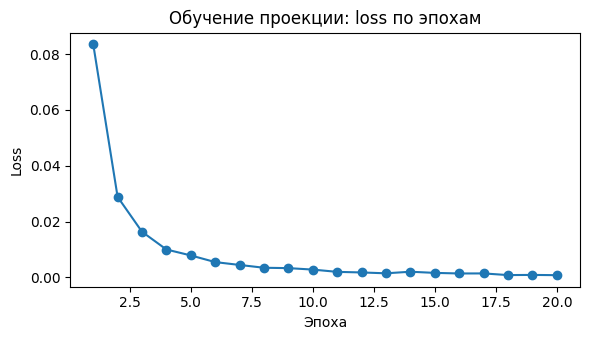

,ndcg_at_10,mrr,recall_at_10,precision_at_5,hit_rate_at_10
method,,,,,
semantic_minilm_full_text,0.230605,0.116813,0.171171,0.048571,0.257143
semantic_minilm_projection,0.095611,0.136431,0.145501,0.058571,0.228571


In [29]:
PROJECTION = {"dimension": 384, "margin": 0.2, "regularization": 0.001, "learning_rate": 0.001, "batch_size": 64, "epochs": 20, "max_negatives": 5}


def build_triplets(dev: pd.DataFrame, engine: SemanticSearch) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """Тройки только из явной разметки development: запрос, релевантный товар, самый похожий размеченный нерелевантный."""
    position = pd.Series(np.arange(len(engine.catalog)), index=engine.catalog.imt_id.astype(int)).to_dict()
    queries = dev.drop_duplicates("query_id").sort_values("query_id")
    query_vectors = dict(zip(queries.query_id, engine.encode_queries(queries.query_text.tolist())))
    anchors, positives, negatives, rows = [], [], [], []
    for query_id, part in dev.groupby("query_id", sort=True):
        part = part.loc[part.item_id.isin(position)]
        pos_ids = sorted(part.loc[part.relevance >= RELEVANCE_THRESHOLD, "item_id"].astype(int))
        neg_ids = sorted(part.loc[part.relevance < RELEVANCE_THRESHOLD, "item_id"].astype(int))
        q = query_vectors[query_id]
        neg_ids = sorted(neg_ids, key=lambda i: (-float(q @ engine.embeddings[position[i]]), i))[: PROJECTION["max_negatives"]]
        for p in pos_ids:
            for n in neg_ids:
                anchors.append(q); positives.append(engine.embeddings[position[p]]); negatives.append(engine.embeddings[position[n]])
        rows.append({"query_id": query_id, "positives": len(pos_ids), "negatives": len(neg_ids), "triplets": len(pos_ids) * len(neg_ids)})
    return np.stack(anchors), np.stack(positives), np.stack(negatives), pd.DataFrame(rows)


def train_projection(anchors: np.ndarray, positives: np.ndarray, negatives: np.ndarray) -> tuple[np.ndarray, pd.DataFrame]:
    torch.manual_seed(SEED)
    dim = PROJECTION["dimension"]
    layer = nn.Linear(dim, dim, bias=False)
    with torch.no_grad():
        layer.weight.copy_(torch.eye(dim))
    optimizer = torch.optim.Adam(layer.parameters(), lr=PROJECTION["learning_rate"])
    tensors = [torch.from_numpy(x) for x in (anchors, positives, negatives)]
    generator = torch.Generator().manual_seed(SEED)
    history = []
    for epoch in range(1, PROJECTION["epochs"] + 1):
        permutation, losses = torch.randperm(len(anchors), generator=generator), []
        for start in range(0, len(permutation), PROJECTION["batch_size"]):
            batch = permutation[start:start + PROJECTION["batch_size"]]
            a, p, n = (F.normalize(layer(t[batch]), dim=1) for t in tensors)
            triplet = F.relu((1 - (a * p).sum(1)) - (1 - (a * n).sum(1)) + PROJECTION["margin"]).mean()
            loss = triplet + PROJECTION["regularization"] * torch.mean((layer.weight - torch.eye(dim)) ** 2)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            losses.append(float(loss.detach()))
        history.append({"epoch": epoch, "loss": float(np.mean(losses))})
    return layer.weight.detach().numpy().astype(np.float32), pd.DataFrame(history)


def project(vectors: np.ndarray, weights: np.ndarray) -> np.ndarray:
    projected = vectors @ weights.T
    return (projected / np.linalg.norm(projected, axis=1, keepdims=True)).astype(np.float32)


class ProjectedSemanticSearch(SemanticSearch):
    def __init__(self, base: SemanticSearch, weights: np.ndarray):
        super().__init__(base.catalog, base.model, project(base.embeddings, weights))
        self.weights = weights

    def encode_queries(self, queries: list[str]) -> np.ndarray:
        return project(super().encode_queries(queries), self.weights)


anchors, positives, negatives, triplet_stats = build_triplets(development, semantic)
projection_weights, loss_history = train_projection(anchors, positives, negatives)
semantic_projected = ProjectedSemanticSearch(semantic, projection_weights)
projected_per_query, projected_top10 = evaluate_search(semantic_projected.search, golden, catalog.imt_id, "semantic_minilm_projection")
results["semantic_minilm_projection"] = (projected_per_query, projected_top10, {"approach": "semantic", "model": f"{SEMANTIC_MODEL} + linear projection",
                                                                              "model_revision": SEMANTIC_REVISION, "product_text": "imt_name . subj_name . description",
                                                                              **{f"projection_{k}": v for k, v in PROJECTION.items()}})

display(triplet_stats[["positives", "negatives", "triplets"]].sum().to_frame("development_total").T)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(loss_history.epoch, loss_history.loss, marker="o")
ax.set(title="Обучение проекции: loss по эпохам", xlabel="Эпоха", ylabel="Loss")
fig.tight_layout()
loss_plot_path = EXPERIMENT_DIR / "projection_loss.png"
fig.savefig(loss_plot_path, dpi=120)
plt.show()
display(summarize_metrics(pd.concat([semantic_per_query, projected_per_query])).set_index("method")[["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5", "hit_rate_at_10"]])

- **Результат и вывод.** Из 560 development-запросов собрано 7 168 троек (1 480 позитивов, 2 710 негативов); динамика loss показана на графике выше. На validation NDCG@10 упал с 0,231 до 0,096, хотя MRR вырос с 0,117 до 0,136, а Precision@5 - с 0,049 до 0,059. Гипотеза отклоняется: линейная проекция, обученная на небольшом числе явных пар, не переносится на новые запросы по ключевой метрике.

#### Выбор конфигурации на validation

Правило, зафиксированное до сравнения: максимальный NDCG@10 (ключевая метрика, использует градуированную разметку), при равенстве - MRR. Test в этот момент не используется.

In [30]:
validation_comparison = (summarize_metrics(pd.concat([per_query for per_query, _, _ in results.values()]))
                         .sort_values(["ndcg_at_10", "mrr"], ascending=False).reset_index(drop=True))
winner = validation_comparison.method.iloc[0]
frozen_selection = {"method": winner, "params": results[winner][2], **{k: PROTOCOL[k] for k in ("catalog_fingerprint", "golden_fingerprint", "relevance_threshold")}}
display(validation_comparison.set_index("method")[["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5", "precision_at_10", "hit_rate_at_10"]].style.format("{:.3f}"))
display(pd.Series({"selected_configuration": winner}).to_frame("value"))

,ndcg_at_10,mrr,recall_at_10,precision_at_5,precision_at_10,hit_rate_at_10
method,,,,,,
hybrid_rrf,0.460,0.157,0.339,0.069,0.074,0.450
lexical_tfidf,0.459,0.169,0.320,0.063,0.070,0.450
semantic_minilm_full_text,0.231,0.117,0.171,0.049,0.041,0.257
semantic_minilm_short_text,0.188,0.144,0.214,0.063,0.047,0.286
semantic_minilm_projection,0.096,0.136,0.146,0.059,0.038,0.229


,value
selected_configuration,hybrid_rrf


**Вывод по `validation_comparison`.** По зафиксированному правилу выбран RRF-гибрид (NDCG@10 = 0,460). Отрыв от TF-IDF (0,459) составляет 0,0007 на 140 запросах и не является устойчивым преимуществом: по сути гибрид равен TF-IDF по NDCG@10, чуть полнее по Recall@10 и Precision@5 и хуже по MRR. Все чисто семантические варианты заметно уступают обоим.

### 2. Финальный тест

Выборка `test` используется один раз - для конфигурации, выбранной выше по validation. Прогон выполняет те же функции поиска и метрик, с тем же порогом, K и каталогом. Результат сохраняется вместе с описанием выбранной конфигурации; при повторном запуске тетради сохранённый результат для той же конфигурации загружается, а не пересчитывается.

In [31]:
RUN_FINAL_TEST_EVAL = True  # конфигурация выбрана по validation выше

ENGINES = {"lexical_tfidf": lexical.search, "semantic_minilm_full_text": semantic.search, "semantic_minilm_short_text": semantic_short.search,
           "hybrid_rrf": hybrid.search, "semantic_minilm_projection": semantic_projected.search}
FINAL_DIR = ARTIFACT_DIR / "final_test"
FINAL_DIR.mkdir(exist_ok=True)
final_state_path = FINAL_DIR / "state.json"

if RUN_FINAL_TEST_EVAL:
    if final_state_path.exists() and json.loads(final_state_path.read_text())["selection"] == json.loads(json.dumps(frozen_selection)):
        final_per_query = pd.read_csv(FINAL_DIR / "per_query_metrics.csv")
        final_top10 = pd.read_csv(FINAL_DIR / "top10.csv")
        final_mode = "loaded_saved_result"
    else:
        queries_test = pd.read_parquet(TEST_QUERIES_PATH)
        assert set(queries_test.query_id).isdisjoint(set(queries_train.query_id))
        final_per_query, final_top10 = evaluate_search(ENGINES[winner], queries_test, catalog.imt_id, f"{winner}_test")
        final_per_query.to_csv(FINAL_DIR / "per_query_metrics.csv", index=False)
        final_top10.to_csv(FINAL_DIR / "top10.csv", index=False)
        final_state_path.write_text(json.dumps({"selection": frozen_selection, "test_queries": int(queries_test.query_id.nunique())}, ensure_ascii=False, indent=2))
        final_mode = "executed"
    final_summary = summarize_metrics(final_per_query)
    final_summary.to_csv(FINAL_DIR / "summary.csv", index=False)
    display(pd.Series({"mode": final_mode, "test_queries": final_per_query.query_id.nunique(), "catalog_size": len(catalog)}).to_frame("value"))
    display(pd.concat([validation_comparison.loc[validation_comparison.method.eq(winner)].assign(split="validation"),
                       final_summary.assign(split="test")]).set_index(["split", "method"])[["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5", "hit_rate_at_10"]].style.format("{:.3f}"))

,value
mode,loaded_saved_result
test_queries,300
catalog_size,4256


,,ndcg_at_10,mrr,recall_at_10,precision_at_5,hit_rate_at_10
split,method,,,,,
validation,hybrid_rrf,0.460,0.157,0.339,0.069,0.450
test,hybrid_rrf_test,0.424,0.152,0.296,0.059,0.407


**Вывод по `final_summary`.** На 300 test-запросах выбранный гибрид получил NDCG@10 = 0,424, MRR = 0,152, Recall@10 = 0,296, Precision@5 = 0,059 и HitRate@10 = 0,407 - на 0,036 ниже validation по NDCG@10, то есть без резкого провала. Test прогнан один раз при первом запуске; при повторном выполнении тетради сохранённый результат загружается (`mode = loaded_saved_result`).

### 3. Трекинг экспериментов в MLflow

Один эксперимент `calmfruits_semantic_search`, отдельный run на каждую конфигурацию и отдельный run финального теста. Логируем параметры (подход, модель, шаблон текста, порог, размер каталога, K, seed, параметры векторизации и эксперимента), все метрики и артефакты: метрики по запросам, сводную таблицу, график сравнения и копию golden-сета. Подключение берётся из `.env` (`MLFLOW_TRACKING_URI`, `MLFLOW_TRACKING_USERNAME`, `MLFLOW_TRACKING_PASSWORD`). Run с тем же именем и тем же отпечатком протокола повторно не создаётся.

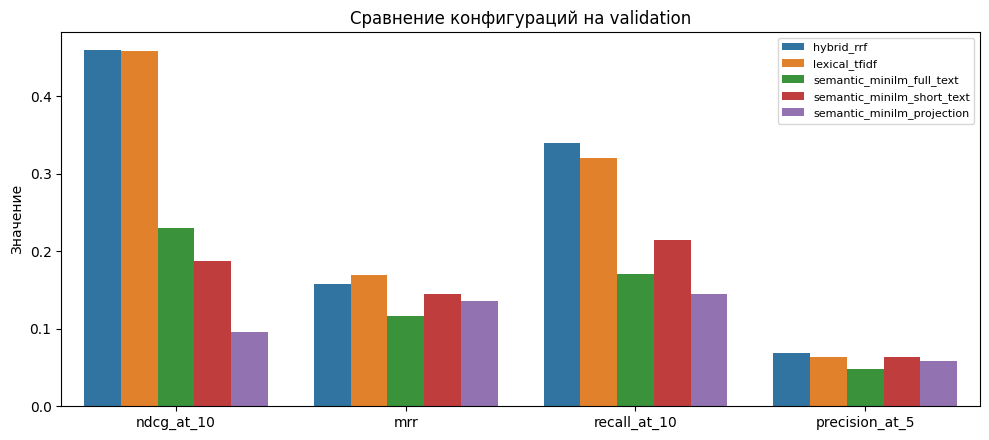

,run_name,run_id
0,lexical_tfidf,ca9f9fdd288043418241b185a0687dfd
1,semantic_minilm_full_text,860d0a1d17bc4828a8398d32cab7fe94
2,semantic_minilm_short_text,63faf39619a34d198aee0419be56bddf
3,hybrid_rrf,a48e19e250434005a9cb3ab1c647f5b0
4,semantic_minilm_projection,ead7dd2d614f42198e2937bf2d1d92de
5,hybrid_rrf_final_test,e141df18da5945cab1a61ff1201c1628


,value
experiment,calmfruits_semantic_search
finished_runs_in_experiment,13


In [32]:
EXPERIMENT_NAME = "calmfruits_semantic_search"
for name in ("MLFLOW_TRACKING_URI", "MLFLOW_TRACKING_USERNAME", "MLFLOW_TRACKING_PASSWORD"):
    assert os.getenv(name), f"{name} не задан в .env"
os.environ.setdefault("MLFLOW_S3_ENDPOINT_URL", os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net"))
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow_client = MlflowClient()
experiment = mlflow_client.get_experiment_by_name(EXPERIMENT_NAME)
experiment_id = experiment.experiment_id if experiment else mlflow_client.create_experiment(EXPERIMENT_NAME)

comparison_plot_path = EXPERIMENT_DIR / "validation_comparison.png"
plot_frame = validation_comparison.melt(id_vars="method", value_vars=["ndcg_at_10", "mrr", "recall_at_10", "precision_at_5"], var_name="metric")
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=plot_frame, x="metric", y="value", hue="method", ax=ax)
ax.set(title="Сравнение конфигураций на validation", xlabel="", ylabel="Значение")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(comparison_plot_path, dpi=120)
plt.show()


def log_run(run_name: str, params: dict, per_query: pd.DataFrame, extra_artifacts: list[Path]) -> str:
    fingerprint = f"{PROTOCOL['catalog_fingerprint']}-{PROTOCOL['golden_fingerprint']}"
    existing = mlflow_client.search_runs([experiment_id], filter_string=(
        f"tags.mlflow.runName = '{run_name}' and params.protocol_fingerprint = '{fingerprint}' and attributes.status = 'FINISHED'"))
    if existing:
        return existing[0].info.run_id
    run_dir = EXPERIMENT_DIR / run_name
    run_dir.mkdir(exist_ok=True)
    summary = summarize_metrics(per_query)
    per_query.to_csv(run_dir / "per_query_metrics.csv", index=False)
    summary.to_csv(run_dir / "summary.csv", index=False)
    all_params = {"method": run_name, "catalog_size": len(catalog), "relevance_threshold": RELEVANCE_THRESHOLD, "k_values": str(K_VALUES),
                  "seed": SEED, "protocol_fingerprint": fingerprint, **params}
    with mlflow.start_run(experiment_id=experiment_id, run_name=run_name) as run:
        mlflow.log_params({k: str(v) for k, v in all_params.items()})
        mlflow.log_metrics({k: float(v) for k, v in summary[METRIC_COLUMNS].iloc[0].items()})
        for path in [run_dir / "per_query_metrics.csv", run_dir / "summary.csv", *extra_artifacts]:
            mlflow.log_artifact(str(path))
        return run.info.run_id


run_ids = {}
for method, (per_query, _, params) in results.items():
    extra = [golden_copy_path, comparison_plot_path] + ([loss_plot_path] if method == "semantic_minilm_projection" else [])
    run_ids[method] = log_run(method, {"eval_split": "validation", **params}, per_query, extra)
run_ids[f"{winner}_final_test"] = log_run(f"{winner}_final_test", {"eval_split": "test", **results[winner][2]}, final_per_query, [FINAL_DIR / "state.json"])

logged = mlflow_client.search_runs([experiment_id], filter_string="attributes.status = 'FINISHED'")
display(pd.DataFrame({"run_name": list(run_ids), "run_id": list(run_ids.values())}))
display(pd.Series({"experiment": EXPERIMENT_NAME, "finished_runs_in_experiment": len(logged)}).to_frame("value"))

Проверка эксперимента скриптом курса: `python check_mlflow.py calmfruits_semantic_search --env-file .env`.

In [33]:
import subprocess

check = subprocess.run([sys.executable, "check_mlflow.py", EXPERIMENT_NAME, "--env-file", ".env"], capture_output=True, text=True, cwd=ROOT)
print(check.stdout[-3000:])
assert check.returncode == 0, check.stderr[-2000:]

Tracking URI : https://mlflow-ds-20260620-97ae288888.infra.data-science.education-services.ru
Эксперимент  : calmfruits_semantic_search
--------------------------------------------------------------
  [OK]  эксперимент найден (id=1)
  [OK]  успешных прогонов: 13 (нужно 2)
--------------------------------------------------------------
  [OK]  hybrid_rrf_final_test
  [OK]  semantic_minilm_projection
  [OK]  hybrid_rrf
  [OK]  semantic_minilm_short_text
  [OK]  semantic_minilm_full_text
  [OK]  lexical_tfidf
  [OK]  lexical_final_test
  [OK]  semantic_projected_validation
  [OK]  hybrid_rrf_validation
  [OK]  semantic_short_text_validation
  [OK]  semantic_full_text_validation
  [OK]  lexical_validation
  [OK]  artifact_smoke_validation
ВСЁ В ПОРЯДКЕ: эксперимент, прогоны, метрики и параметры на месте.



### 4. Финальные выводы

#### 4.1. Сводная таблица

In [34]:
final_table = pd.concat([validation_comparison.assign(split="validation"), final_summary.assign(split="test")], ignore_index=True)
final_table = final_table.set_index(["split", "method"])[["ndcg_at_10", "mrr", "precision_at_1", "precision_at_5", "recall_at_10", "hit_rate_at_10"]]
display(final_table.style.format("{:.3f}"))

**Вывод по `final_table`.** Лучшая конфигурация по NDCG@10 - RRF-гибрид TF-IDF и MiniLM с весом семантики 0,1: 0,460 на validation и 0,424 на test. Относительно лексического baseline он лучше по NDCG@10, Recall@10 и Precision@5, но хуже по MRR и P@1; относительно семантического baseline - в два раза лучше по NDCG@10 (0,460 против 0,231). Выбор сделан по NDCG@10, так как только она учитывает градуированную разметку 0–3.

#### 4.2. Качественный анализ

Три test-запроса, на которых выбранная конфигурация ошибается сильнее всего, их топ-5 и лучший размеченный товар.

In [35]:
worst_test = final_per_query.nsmallest(3, "ndcg_at_10")[["query_id", "query_text", "ndcg_at_10", "mrr", "reachable_relevant_share", "labeled_share_at_10"]]
display(worst_test)
display(final_top10.merge(worst_test[["query_id"]], on="query_id").query("rank <= 5")[["query_text", "rank", "imt_name", "subj_name", "relevance"]])
test_labels = pd.read_parquet(TEST_QUERIES_PATH).merge(worst_test[["query_id"]], on="query_id")
best_labeled = (test_labels.sort_values("relevance", ascending=False).drop_duplicates("query_id")
                .merge(catalog[["imt_id", "imt_name", "subj_name", "has_description"]], left_on="item_id", right_on="imt_id", how="left"))
display(best_labeled[["query_text", "relevance", "imt_name", "subj_name", "has_description"]])

,query_id,query_text,ndcg_at_10,mrr,reachable_relevant_share,labeled_share_at_10
30,SYN_000113,футболки lovetex store,0.00000,0.006061,1.0,0.0
273,SYN_000913,анораки puma,0.00000,0.071429,1.0,0.0
129,SYN_000456,костюмы на пуговицах,0.07317,0.045455,1.0,0.1


,query_text,rank,imt_name,subj_name,relevance
0,футболки lovetex store,1,Фудболка,Футболки,0
1,футболки lovetex store,2,Футболка DASHAEV Stamp,Футболки,0
2,футболки lovetex store,3,Футболки,Футболки,0
3,футболки lovetex store,4,"Футболка ""Cocktail""",Футболки,0
4,футболки lovetex store,5,Футболка Simply,Футболки,0
10,костюмы на пуговицах,1,Костюмы,Костюмы,1
11,костюмы на пуговицах,2,Плащ,Плащи,0
12,костюмы на пуговицах,3,"Платье вечернее ""Jennifer""/Летний сарафан/Бело...",Платья,0
13,костюмы на пуговицах,4,Костюм,Костюмы,0
14,костюмы на пуговицах,5,Лето,Костюмы,0


,query_text,relevance,imt_name,subj_name,has_description
0,футболки lovetex store,3,Футболка женская принт большие размеры,Футболки,True
1,костюмы на пуговицах,3,Костюмы,Костюмы,True
2,анораки puma,3,Анорак Train FM Xtreme Woven Jacket,Анораки,True


**Вывод по `worst_test` и выдаче.** Типичные ошибки выбранной конфигурации:

- **Бренд не попадает в текст товара.** "футболки lovetex store" (NDCG@10 = 0): в выдаче футболки других брендов, а релевантная карточка "Футболка женская принт большие размеры" не содержит бренда в `product_text` - такие запросы не решаются без поля бренда.
- **Бренд перевешивает тип товара.** "анораки puma" (NDCG@10 = 0): в топ-5 кроссовки и леггинсы PUMA, худи, футболка и куртка, а анорак (оценка 3) в топ-10 не попал.
- **Атрибут игнорируется.** "костюмы на пуговицах" (NDCG@10 = 0,073): выдача - костюмы вообще, плащ и платье; признак "на пуговицах" не влияет на ранжирование.

Во всех трёх случаях релевантный товар есть в каталоге (`reachable_relevant_share = 1`), а в топ-10 почти нет размеченных товаров, то есть часть выдачи не оценена асессорами. Ошибки согласуются с метриками: высокий HitRate@10 при низком MRR означает, что релевантное находится, но не на первых позициях.

#### 4.3. Ограничения оценки

In [36]:
limitations_evidence = pd.Series({
    "prepared_catalog_cards": len(full_catalog),
    "evaluation_catalog_cards": len(catalog),
    "test_mean_labeled_share_in_top10": final_per_query.labeled_share_at_10.mean(),
    "test_mean_ndcg_upper_bound_at_10": final_per_query.ndcg_upper_bound_at_10.mean(),
    "test_mean_relevant_items_per_query": final_per_query.relevant_items.mean(),
    "validation_queries": golden.query_id.nunique(),
    "test_queries": final_per_query.query_id.nunique(),
}).to_frame("value")
display(limitations_evidence)

,value
prepared_catalog_cards,48376.000000
evaluation_catalog_cards,4256.000000
test_mean_labeled_share_in_top10,0.824000
test_mean_ndcg_upper_bound_at_10,1.000000
test_mean_relevant_items_per_query,2.266667
validation_queries,140.000000
test_queries,300.000000


- Разметка синтетическая и пулированная: каталог оценки - 4 256 карточек пула асессоров из 48 376 подготовленных. Неразмеченные товары считаются нерелевантными; в топ-10 на test размечено 82,4% товаров, так что метрики - оценка снизу.
- На запрос в среднем 2,3 релевантных товара на test, поэтому Precision@10 физически не может быть высоким.
- Выборки небольшие: 140 validation- и 300 test-запросов; разницы порядка 0,001 NDCG@10 не значимы.
- Запросы сгенерированы, а не собраны от пользователей; домен ограничен категориями "Одежда" и "Обувь".
- MiniLM имеет лимит 128 токенов и обрезает 27,6% полных текстов пула; эксперименты выполнены на CPU без полного fine-tuning.
- 62,6% карточек MVP не имеют описания; такие карточки занимают большинство первых позиций выдачи (раздел 5 недели 2).

#### 4.4. Рекомендация бизнесу

Заменять текущий поиск по ключевым словам векторным не стоит: чистый семантический поиск на этом каталоге вдвое хуже лексического по NDCG@10 (0,231 против 0,459) и путает типы товаров. Если развивать векторный поиск, то только как добавку к лексическому - гибрид с небольшим весом семантики. Он не хуже TF-IDF (NDCG@10 0,460 на validation, 0,424 на test) и чуть чаще приводит в топ-10 подходящие товары (Recall@10 0,339 против 0,320), но первый подходящий товар показывает не раньше. Гибрид полезен для запросов с типом товара и неточными формулировками; он ошибается на брендовых запросах и запросах с конкретными атрибутами (фасон, застёжка). Прирост небольшой, поэтому перед внедрением его нужно подтвердить A/B-тестом на реальных пользователях; главный резерв качества сейчас - сам каталог: у 62,6% карточек нет описания.

#### 4.5. Дальнейшие шаги

1. **Убрать перекос в сторону карточек без описания.** Они занимают около 90% первых позиций при 22,5% каталога и ни разу не были релевантными в golden-сете: стоит понизить их вес в ранжировании или обогатить их текст атрибутами, а продавцам - заполнять описания.
2. **Добавить бренд и атрибуты как отдельные поля и фильтры** поверх выдачи: ошибки на брендовых и атрибутивных запросах этого требуют.
3. **Собрать реальные логи запросов, кликов и покупок** и доразметить популярные неоценённые товары из топ-10 - так метрики перестанут занижаться неполной разметкой.
4. **Проверить другую модель эмбеддингов** (русскоязычную или с окном больше 128 токенов) и дообучение на логах, сохраняя деление запросов на обучение и валидацию по тексту запроса без утечки.
5. **При росте каталога перейти на ANN-индекс** (FAISS, HNSW) и контролировать его полноту относительно точного поиска.